In [618]:
import pandas as pd
import numpy as np
from bs4 import BeautifulSoup
import requests
import os
import re
import geopandas as gpd
import copy

import importlib
import helper_functions.serviceArea
import helper_functions.mrt_buffer

importlib.reload(helper_functions.serviceArea)
importlib.reload(helper_functions.mrt_buffer)

import helper_functions.OneMapAPI as OneMapAPI
import helper_functions.serviceArea as serviceArea
import helper_functions.mrt_buffer as mrt_buffer
import osmnx as ox

# Import walking network

In [215]:
# import walking network
save_dir = os.path.join(os.getcwd(),"Data","Road_Networks")
filename = "SG_walk_network.graphml"
G_walk = ox.load_graphml(os.path.join(save_dir, filename))

# Import planning area

<class 'geopandas.geodataframe.GeoDataFrame'>


array(['BEDOK', 'BOON LAY', 'BUKIT BATOK', 'BUKIT MERAH', 'BUKIT PANJANG',
       'BUKIT TIMAH', 'CENTRAL WATER CATCHMENT', 'CHANGI',
       'CHOA CHU KANG', 'CLEMENTI', 'HOUGANG', 'JURONG EAST',
       'JURONG WEST', 'PASIR RIS', 'PIONEER', 'PUNGGOL', 'QUEENSTOWN',
       'SELETAR', 'SEMBAWANG', 'SENGKANG', 'SERANGOON', 'KALLANG',
       'LIM CHU KANG', 'NORTH-EASTERN ISLANDS', 'NOVENA', 'SIMPANG',
       'SOUTHERN ISLANDS', 'SUNGEI KADUT', 'TOA PAYOH', 'TUAS',
       'WESTERN ISLANDS', 'WESTERN WATER CATCHMENT', 'WOODLANDS',
       'RIVER VALLEY', 'ROCHOR', 'SINGAPORE RIVER', 'STRAITS VIEW',
       'CHANGI BAY', 'MARINE PARADE', 'DOWNTOWN CORE', 'MARINA EAST',
       'MARINA SOUTH', 'MUSEUM', 'NEWTON', 'ORCHARD', 'OUTRAM',
       'TAMPINES', 'TANGLIN', 'TENGAH', 'MANDAI', 'BISHAN', 'ANG MO KIO',
       'GEYLANG', 'PAYA LEBAR', 'YISHUN'], dtype=object)

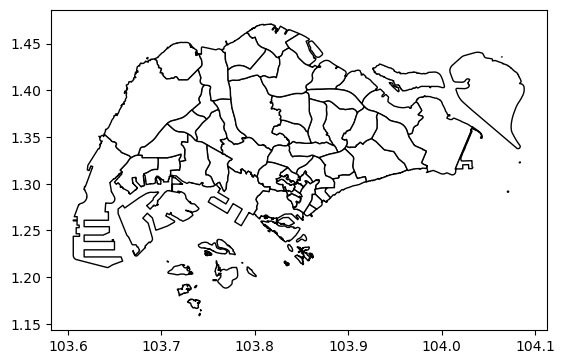

In [24]:
planningArea_noSea = gpd.read_file(r"C:\Users\hypak\OneDrive - Singapore Management University\Documents\Data\SG_Masterplan\MasterPlan2019PlanningAreaBoundaryNoSea.geojson")

def extract_html_tags(row):
    html_content = row["Description"]
    soup = BeautifulSoup(html_content,"html.parser")
    ths = soup.find_all('th')
    tds = soup.find_all('td')
    column_names = []
    column_values = []
    for th in ths:
        column_names.append(th.get_text())
    for td in tds:
        column_values.append(td.get_text())
    column_names = column_names[1:] # remove the first "Attribute"
    return pd.Series({k:v for k,v in zip(column_names,column_values)})
# column_names, _ = extract_html_tags(planningArea_noSea.iloc[0,1])
planningArea_shp = planningArea_noSea.join(planningArea_noSea.apply(extract_html_tags,axis=1))
print(type(planningArea_shp))
planningArea_shp.plot(fc='white',ec='k')
planningArea_shp['PLN_AREA_N'].unique()

# Import residential data

In [518]:
residential_transaction_df = pd.read_csv(r"Exported_Data\Residential_transaction_2014_2024.csv")
# columns to change to numeric
numeric_columns = [c for c in residential_transaction_df.columns if bool(re.search(".*Price.*|^Area.*",c))]
residential_transaction_df[numeric_columns] = residential_transaction_df[numeric_columns].apply(lambda x: pd.to_numeric(x.str.replace(',', ''),errors="coerce"),axis=0)
# change date to datetime format
residential_transaction_df['Sale Date'] = residential_transaction_df['Sale Date'].apply(lambda x: pd.to_datetime(x, format='%d %b %Y', errors='coerce')) 
# get year and month columns
residential_transaction_df["year"] = residential_transaction_df['Sale Date'].dt.year.astype(int)
residential_transaction_df["month"] = residential_transaction_df['Sale Date'].dt.month.astype(int)
# rename columns
rename_columns = {"Planning Region": "REGION_N", "Planning Area":"PLN_AREA_N","Sale Date":"Sale_Date"}
residential_transaction_df = residential_transaction_df.rename(columns=rename_columns)
# strip leading and trailing white spaces from PLN_AREA_N because Changi has trailing white spaces
residential_transaction_df['PLN_AREA_N'] = residential_transaction_df['PLN_AREA_N'].str.strip()
# drop rows with missing longitude and latitude because they are either land or enbloc properties - removal of 494 rows
residential_transaction_df = residential_transaction_df.dropna(subset=['LONGITUDE','LATITUDE'])
# convert cordinates to point geometry
residential_transaction_df = gpd.GeoDataFrame(residential_transaction_df, 
                                              geometry=gpd.points_from_xy(residential_transaction_df['LONGITUDE'], residential_transaction_df['LATITUDE']), 
                                              crs=planningArea_shp.crs)
# add nodesID for properties
# residential_transaction_df['nodesID_property'] = ox.nearest_nodes(G_car,X=residential_transaction_df['longitude'], Y=residential_transaction_df['latitude'])
print("Length of residential transaction df: ", len(residential_transaction_df))
print(residential_transaction_df.dtypes)

Length of residential transaction df:  267452
Project Name                           object
Transacted Price ($)                    int64
Area (SQFT)                           float64
Unit Price ($ PSF)                      int64
Sale_Date                      datetime64[ns]
Address                                object
Type of Sale                           object
Type of Area                           object
Area (SQM)                            float64
Unit Price ($ PSM)                      int64
Nett Price($)                         float64
Property Type                          object
Number of Units                         int64
Tenure                                 object
Completion Date                        object
Purchaser Address Indicator            object
Postal Code                             int64
Postal District                         int64
Postal Sector                           int64
REGION_N                               object
PLN_AREA_N                        

# Import MRT and LRT stations

In [596]:
# trainStations_400m = gpd.read_file(r"Exported_Data\mrt_stations_buffer400m.shp")
# trainStations_400m.plot()
# print("Number of missing geometry: ",len(trainStations_400m[trainStations_400m["geometry"].isna()]))
# trainStations_400m["opening_date"] = pd.to_datetime(trainStations_400m["opening_da"])
# trainStations_400m.head()
# trainStations_400m[trainStations_400m["stn_name"]=="OUTRAM PARK MRT STATION"]
#-------------- get 400m polygon geometry from MRT stations----------------------
trainStations = pd.read_csv(r"Exported_Data\MRT_opening\MRT_stations_opening.csv")
# trainStations = trainStations.dropna(subset=["stn_code"])
# trainStations["mrt_line"] = trainStations['stn_code'].apply(lambda x: re.search(r"[A-Z]{2,3}", x).group(0))
# remove stns that are not open yet
trainStations = trainStations[~trainStations["mrt_line"].isin(["JE","JS","JW","CR"])]
# convert cordinates to point geometry
trainStations_400m = gpd.GeoDataFrame(trainStations,
                                 geometry=gpd.points_from_xy(trainStations['LONGITUDE'], trainStations['LATITUDE']), 
                                              crs=planningArea_shp.crs)
# trainStations = trainStations.loc[trainStations[["stn_name","stn_code","geometry"]].drop_duplicates().index]
# trainStations[trainStations["stn_name"]=="OUTRAM PARK MRT STATION"]

# calculate buffer for train station using euclidean distance
trainStations_400m_buffer = serviceArea.add_buffer(trainStations_400m,buffer_dist=400,plot=False)
# trainStations_400m["geometry"] = trainStations_400m_buffer["geometry"]
trainStations_400m.loc[trainStations_400m_buffer.index,"geometry"] = trainStations_400m_buffer
trainStations_400m["opening_date"] = pd.to_datetime(trainStations_400m["opening_date"])
trainStations_400m
# # calculate service area via walking distance
# GSA = serviceArea.GetServiceArea(G_walk,trainStations,radius=400)
# nodes = GSA.get_nearest_nodes(latitude_column="LATITUDE",longitude_column="LONGITUDE")
# # plot nodes corresponding to MRT stations
# # GSA.plot_nodes(nodes)
# # create convex hull if valid, otherwise use buffer
# trainStations_400m = GSA.get_serviceArea_polygons(nodes)
# trainStations_400m = trainStations_400m.set_index(trainStations.index)
# # assign geometry for nonNA geometry
# trainStations.loc[~trainStations_400m["geometry"].isna(),"geometry"] = trainStations_400m.loc[~trainStations_400m["geometry"].isna(),"geometry"]
# # trainStations["nodesID_walk"] = trainStations_400m[0]
# # trainStations["geometry"] = trainStations_400m["geometry"]

# # calculate service area via euclidean distance (buffer)
# trainStations_400m_buffer = serviceArea.add_buffer(trainStations,buffer_dist=400,plot=False)
# trainStations.loc[trainStations_400m["geometry"].isna(),"geometry"] = trainStations_400m_buffer.loc[trainStations_400m["geometry"].isna()]

# print("Number of missing geometry: ",len(trainStations[trainStations["geometry"].isna()]))
# trainStations.plot()
# trainStations.to_file(r"Exported_Data\mrt_stations_buffer400m.shp",driver='ESRI Shapefile')


,mrt_code,stn_name,opening_date,year,month,interchange_number,mrt_line,stn_code,SEARCHVAL,BLK_NO,ROAD_NAME,BUILDING,ADDRESS,POSTAL,X,Y,LATITUDE,LONGITUDE,geometry
0,NS10,ADMIRALTY MRT STATION,1996-02-10,1996.0,2.0,1.0,NS,NS10,ADMIRALTY MRT STATION (NS10),70,WOODLANDS AVENUE 7,ADMIRALTY MRT STATION (NS10),70 WOODLANDS AVENUE 7 ADMIRALTY MRT STATION (N...,738344,24402.386627,46918.506802,1.440589,103.800991,"POLYGON ((103.80458 1.44059, 103.80457 1.44023..."
1,EW9,ALJUNIED MRT STATION,1989-11-04,1989.0,11.0,1.0,EW,EW9,ALJUNIED MRT STATION (EW9),81,LORONG 25 GEYLANG,ALJUNIED MRT STATION (EW9),81 LORONG 25 GEYLANG ALJUNIED MRT STATION (EW9...,388310,33518.604869,33190.002017,1.316433,103.882906,"POLYGON ((103.8865 1.31643, 103.88648 1.31608,..."
3,NS16 CR11,ANG MO KIO MRT STATION,1987-11-07,1987.0,11.0,1.0,NS,NS16,ANG MO KIO MRT STATION (NS16),2795,ANG MO KIO AVENUE 8,ANG MO KIO MRT STATION (NS16),2795 ANG MO KIO AVENUE 8 ANG MO KIO MRT STATIO...,569812,29807.261147,39105.735995,1.369933,103.849558,"POLYGON ((103.85315 1.36993, 103.85313 1.36958..."
4,SE3,BAKAU LRT STATION,2003-01-18,2003.0,1.0,1.0,SE,SE3,BAKAU LRT STATION (SE3),50,RIVERVALE DRIVE,BAKAU LRT STATION (SE3),50 RIVERVALE DRIVE BAKAU LRT STATION (SE3) SIN...,545053,36023.433345,41102.996687,1.387994,103.905415,"POLYGON ((103.90901 1.38799, 103.90899 1.38764..."
5,BP9,BANGKIT LRT STATION,1999-11-06,1999.0,11.0,1.0,BP,BP9,BANGKIT LRT STATION (BP9),20,BUKIT PANJANG RING ROAD,BANGKIT LRT STATION (BP9),20 BUKIT PANJANG RING ROAD BANGKIT LRT STATION...,679939,21248.056588,40221.448411,1.380022,103.772647,"POLYGON ((103.77624 1.38002, 103.77622 1.37967..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
214,TE3,WOODLANDS SOUTH MRT STATION,2020-01-31,2020.0,1.0,1.0,TE,TE3,WOODLANDS SOUTH MRT STATION (TE3),30,WOODLANDS DRIVE 17,WOODLANDS SOUTH MRT STATION (TE3),30 WOODLANDS DRIVE 17 WOODLANDS SOUTH MRT STAT...,737741,23542.554570,45459.758822,1.427396,103.793264,"POLYGON ((103.79686 1.4274, 103.79684 1.42704,..."
215,NE11,WOODLEIGH MRT STATION,2011-06-20,2011.0,6.0,1.0,NE,NE11,WOODLEIGH MRT STATION (NE11),400,UPPER SERANGOON ROAD,WOODLEIGH MRT STATION (NE11),400 UPPER SERANGOON ROAD WOODLEIGH MRT STATION...,347695,32173.318575,35706.379363,1.339190,103.870818,"POLYGON ((103.87441 1.33919, 103.87439 1.33884..."
216,NS5,YEW TEE MRT STATION,1996-02-10,1996.0,2.0,1.0,NS,NS5,YEW TEE MRT STATION (NS5),61,CHOA CHU KANG DRIVE,YEW TEE MRT STATION (NS5),61 CHOA CHU KANG DRIVE YEW TEE MRT STATION (NS...,689715,18438.983117,42158.018102,1.397535,103.747405,"POLYGON ((103.751 1.39754, 103.75098 1.39718, ..."
217,NS15,YIO CHU KANG MRT STATION,1987-11-07,1987.0,11.0,1.0,NS,NS15,YIO CHU KANG MRT STATION (NS15),3000,ANG MO KIO AVENUE 8,YIO CHU KANG MRT STATION (NS15),3000 ANG MO KIO AVENUE 8 YIO CHU KANG MRT STAT...,569813,29294.126233,40413.062636,1.381756,103.844947,"POLYGON ((103.84854 1.38176, 103.84852 1.3814,..."


# Merge MRT/LRT buffers with residential properties

Perform a spatial join year by year of the property sale

1. for each property transaction (`property_Y`), filter the trainStation df up to (`train_Y+1`) of the MRT's opening date (to include upcoming MRT stations)
2. Conduct a spatial join of the `property_Y` and `train_Y+1` to calculate how many existing and upcoming mrt stations that are within 400m buffer → `residential_train_Y`
3. Create columns - "number of existing mrt", "number of upcoming mrt", "mrt_lines" (list of sorted mrt line, station code not required)
4. That way, for each transaction record, we have other MRT attribute data

In [619]:
residential_train = mrt_buffer.add_mrt_buffer(residential_transaction_df, trainStations_400m,
                          address_column = "Address", sale_date_column = "Sale_Date",
                            construction_period = 6)
residential_train

length of df after spatial joining residential and train df:  299291
length of train df:  267452
length of df after merging residential and train df:  267452


,Project Name,Transacted Price ($),Area (SQFT),Unit Price ($ PSF),Sale_Date,Address,Type of Sale,Type of Area,Area (SQM),Unit Price ($ PSM),...,X,Y,LATITUDE,LONGITUDE,year,month,geometry,existing_stn_count,upcoming_stn_count,stn_lines
0,CASTLE GREEN,950000,1151.75,825,2014-01-02,481 YIO CHU KANG ROAD #05-02,Resale,Strata,107.0,8879,...,28883.630900,40954.900104,1.386656,103.841259,2014,1,POINT (103.84126 1.38666),0,0,none
1,SUMMERHILL,1650000,1550.02,1065,2014-01-02,52 HUME AVENUE #01-16,Resale,Strata,144.0,11458,...,20479.219140,37907.302875,1.359094,103.765739,2014,1,POINT (103.76574 1.35909),0,0,none
2,THOMSON THREE,1051000,731.95,1436,2014-01-02,41 BRIGHT HILL DRIVE #14-01,New Sale,Strata,68.0,15456,...,27661.184826,37765.008907,1.357808,103.830274,2014,1,POINT (103.83027 1.35781),0,0,none
3,KINGSFORD . HILLVIEW PEAK,730000,516.67,1413,2014-01-03,103 HILLVIEW RISE #10-11,New Sale,Strata,48.0,15208,...,20304.463939,38537.214606,1.364790,103.764169,2014,1,POINT (103.76417 1.36479),0,0,none
4,MEADOWS @ PEIRCE,2518000,3035.45,830,2014-01-03,628 UPPER THOMSON ROAD #05-61,Resale,Strata,282.0,8929,...,27381.798079,40248.119710,1.380264,103.827764,2014,1,POINT (103.82776 1.38026),0,0,none
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
267447,THE TRE VER,2300000,1097.93,2095,2025-06-18,66 POTONG PASIR AVENUE 1 #13-30,Sub Sale,Strata,102.0,22549,...,31436.687533,35557.251883,1.337841,103.864199,2025,6,POINT (103.8642 1.33784),0,0,none
267448,TWIN FOUNTAINS,1600000,1205.57,1327,2025-06-18,19 WOODLANDS AVENUE 6 #05-26,Resale,Strata,112.0,14286,...,24248.043549,45896.792457,1.431349,103.799604,2025,6,POINT (103.7996 1.43135),0,0,none
267449,BARTLEY RIDGE,890000,559.73,1590,2025-06-19,46 MOUNT VERNON ROAD #01-47,Resale,Strata,52.0,17115,...,33357.349916,35916.628376,1.341091,103.881458,2025,6,POINT (103.88146 1.34109),1,0,CC
267450,THE WOODLEIGH RESIDENCES,1865000,742.72,2511,2025-06-20,21 BIDADARI PARK DRIVE #10-26,Sub Sale,Strata,69.0,27029,...,32238.669180,35625.737646,1.338461,103.871406,2025,6,POINT (103.87141 1.33846),1,0,NE


### Residential and train merging

In [617]:
residential_train = residential_transaction_df.sjoin(trainStations_400m,how="left",
    rsuffix="train",lsuffix="property")
print("length of df after spatial joining residential and train df: ",len(residential_train))
def get_train_columns(df_subset,construction_period=6):
    stn_dict = {"existing_stn_count": 0, "upcoming_stn_count": 0, "stn_lines":"none"}
    if df_subset["opening_date"].notna().sum() > 0:
        train_date = df_subset["opening_date"]
        train_date_soon = train_date - pd.DateOffset(months=construction_period)
        train_year = df_subset["year_train"]
        sale_date = df_subset["Sale_Date"]
        sale_year = df_subset["year_property"]

        mask0 = ((sale_date >= train_date_soon) & (sale_date < train_date)) | (sale_year == train_year - 1)
        stn_dict["upcoming_stn_count"] = mask0.sum()
        mask1 = sale_date >= train_date
        stn_dict["existing_stn_count"] = mask1.sum()
        valid_mrt_lines = df_subset.loc[(mask0|mask1),"mrt_line"].to_list()
        stn_dict["stn_lines"] = ','.join(sorted(set(valid_mrt_lines)))

        return pd.Series(stn_dict, index = list(stn_dict))
   
    return pd.Series(stn_dict, index = list(stn_dict))
    

# x = residential_train[(residential_train["Address"] == "1 PEARL BANK #22-06") & (residential_train["year_property"]==2021)].tail(3)
# x
# get_train_columns(x,construction_period=6)
# residential_train[residential_train["stn_code"] == "TE17"]
# residential_train[residential_train["Project Name"]=="PEARL BANK APARTMENT"].sort_values(by="Sale_Date")
# group by Address and Sale_Date to get specific transaction
residential_train_columns = residential_train.groupby(["Address","Sale_Date"]).apply(lambda x: get_train_columns(x,construction_period=6)).reset_index(level=[0,1])
print("length of train df: ",len(residential_train_columns))
residential_train = residential_transaction_df.merge(residential_train_columns,on=["Address","Sale_Date"])
print("length of df after merging residential and train df: ",len(residential_train))

length of df after spatial joining residential and train df:  299291


C:\Users\hypak\AppData\Local\Temp\ipykernel_27300\2355493525.py:31: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  residential_train_columns = residential_train.groupby(["Address","Sale_Date"]).apply(lambda x: get_train_columns(x,construction_period=6)).reset_index(level=[0,1])


length of train df:  267452
length of df after merging residential and train df:  267452


1. intersect train station buffer with residential areas
2. identify project names that are within train station buffer
3. for each project name, sort by date, before train completion date, set "within_train_buffer" as False, after train completion date, set as True

### Get MRT locations
- do not use train Exits because we don't know when each exit was built

In [ ]:
# station = "BAYFRONT MRT STATION"
# pattern = re.compile(rf'^{station}(?: \([A-Z]{{2,3}}(\d{{1,2}})?(\s?\/\s?.+)?\))?$', re.IGNORECASE)
# bool(pattern.match("BAYFRONT MRT STATION"))
# OneMapAPI.get_coordinates_from_location("BAYFRONT MRT STATION" ,headers=headers)

True

In [ ]:
trainStations = pd.read_csv(r"Exported_Data\MRT_opening\MRT_LRT_stations_opening.csv")
trainStations['stn_code'] = trainStations['mrt_code'].apply(lambda x: x.split(' ')[0])
print("length of df: ",len(trainStations))
def get_mrt_line_locations(trainStations):
    matched_str = [] # store results
    headers = OneMapAPI.generate_OneMap_headers()
    # get unique MRT station to avoid repeated search
    unique_trainStations = trainStations["stn_name"].unique()
    for stn in unique_trainStations:
        results = OneMapAPI.get_coordinates_from_location(stn,headers=headers)
        station = stn.strip()
        pattern = re.compile(rf'^{station}(?: \([A-Z]{{2,3}}(\d{{1,2}})?(\s?\/\s?.+)?\))?$', re.IGNORECASE)
        for result in results:
            t = result['SEARCHVAL']
            if bool(pattern.match(t)):
                # extract station code within the brackets
                result["stn_name"] = station
                stn_code = re.search(r"\s\((.*?)\)", t)
                if stn_code:
                    result['stn_code'] = stn_code.group(1).strip()
                    result['mrt_line'] = re.search(r"[A-Z]{2,3}", result['stn_code']).group(0)
                else:
                    result['stn_code'] = None
                    result['mrt_line'] = None
                matched_str.append(result)

    return pd.DataFrame(matched_str)
mrt_location_df = get_mrt_line_locations(trainStations)
print("length of df: ",len(mrt_location_df))
mrt_location_df = mrt_location_df.dropna(subset="stn_code")
print("length of df: ",len(mrt_location_df))


length of df:  213
length of df:  252
length of df:  212


,mrt_code,stn_name,opening_date,year,month,interchange_number,mrt_line,stn_code,SEARCHVAL,BLK_NO,ROAD_NAME,BUILDING,ADDRESS,POSTAL,X,Y,LATITUDE,LONGITUDE
39,NS10,ADMIRALTY MRT STATION,1996-02-10,1996,2,1,NS,NS10,ADMIRALTY MRT STATION (NS10),70,WOODLANDS AVENUE 7,ADMIRALTY MRT STATION (NS10),70 WOODLANDS AVENUE 7 ADMIRALTY MRT STATION (N...,738344,24402.3866267931,46918.506801948,1.44058856161847,103.800990519771
22,EW9,ALJUNIED MRT STATION,1989-11-04,1989,11,1,EW,EW9,ALJUNIED MRT STATION (EW9),81,LORONG 25 GEYLANG,ALJUNIED MRT STATION (EW9),81 LORONG 25 GEYLANG ALJUNIED MRT STATION (EW9...,388310,33518.6048692847,33190.002017457,1.3164326118157,103.882906044385
0,NS16 CR11,ANG MO KIO MRT STATION,1987-11-07,1987,11,1,NS,NS16,ANG MO KIO MRT STATION (NS16),2795,ANG MO KIO AVENUE 8,ANG MO KIO MRT STATION (NS16),2795 ANG MO KIO AVENUE 8 ANG MO KIO MRT STATIO...,569812,29807.2611468043,39105.7359950263,1.36993284962262,103.84955809232
61,SE3,BAKAU LRT STATION,2003-01-18,2003,1,1,SE,SE3,BAKAU LRT STATION (SE3),50,RIVERVALE DRIVE,BAKAU LRT STATION (SE3),50 RIVERVALE DRIVE BAKAU LRT STATION (SE3) SIN...,545053,36023.4333449397,41102.9966866206,1.38799431054768,103.905415300171
45,BP9,BANGKIT LRT STATION,1999-11-06,1999,11,1,BP,BP9,BANGKIT LRT STATION (BP9),20,BUKIT PANJANG RING ROAD,BANGKIT LRT STATION (BP9),20 BUKIT PANJANG RING ROAD BANGKIT LRT STATION...,679939,21248.0565876467,40221.4484106153,1.38002223010088,103.772647370452
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,TE3,WOODLANDS SOUTH MRT STATION,2020-01-31,2020,1,1,TE,TE3,WOODLANDS SOUTH MRT STATION (TE3),30,WOODLANDS DRIVE 17,WOODLANDS SOUTH MRT STATION (TE3),30 WOODLANDS DRIVE 17 WOODLANDS SOUTH MRT STAT...,737741,23542.5545697259,45459.758821588,1.42739605281442,103.79326432221
112,NE11,WOODLEIGH MRT STATION,2011-06-20,2011,6,1,NE,NE11,WOODLEIGH MRT STATION (NE11),400,UPPER SERANGOON ROAD,WOODLEIGH MRT STATION (NE11),400 UPPER SERANGOON ROAD WOODLEIGH MRT STATION...,347695,32173.3185749156,35706.3793633711,1.33919004519388,103.87081830915
44,NS5,YEW TEE MRT STATION,1996-02-10,1996,2,1,NS,NS5,YEW TEE MRT STATION (NS5),61,CHOA CHU KANG DRIVE,YEW TEE MRT STATION (NS5),61 CHOA CHU KANG DRIVE YEW TEE MRT STATION (NS...,689715,18438.9831173802,42158.0181021616,1.39753506936297,103.747405150236
4,NS15,YIO CHU KANG MRT STATION,1987-11-07,1987,11,1,NS,NS15,YIO CHU KANG MRT STATION (NS15),3000,ANG MO KIO AVENUE 8,YIO CHU KANG MRT STATION (NS15),3000 ANG MO KIO AVENUE 8 YIO CHU KANG MRT STAT...,569813,29294.1262330338,40413.0626359228,1.38175587099132,103.84494727118


In [ ]:

trainStations_merged = trainStations.merge(mrt_location_df,how="outer",on=["stn_name","mrt_line","stn_code"]).sort_values(by="stn_name")#
# trainStations_merged[trainStations_merged['LATITUDE'].isna()]

trainStations_merged = trainStations_merged.groupby(["stn_name"]).apply(lambda x: x.ffill().bfill()).reset_index(drop=True).drop_duplicates(subset=["stn_name","mrt_line","opening_date"],keep='first')
# trainStations_merged[trainStations_merged["stn_name"]=="MARINA BAY MRT STATION"]
# print("missing mrt stns: ",set(trainStations["stn_name"]) - set(trainStations_merged["stn_name"]))
print("length of df: ",len(trainStations_merged))
trainStations_merged#.to_csv(r"Exported_Data\MRT_opening\MRT_stations_opening.csv",index=False)

length of df:  219


C:\Users\hypak\AppData\Local\Temp\ipykernel_27300\1835226186.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  trainStations_merged = trainStations_merged.groupby(["stn_name"]).apply(lambda x: x.ffill().bfill()).reset_index(drop=True).drop_duplicates(subset=["stn_name","mrt_line","opening_date"],keep='first')


### Scrap MRT stations and operation date from wikipedia

In [ ]:
url = "https://en.wikipedia.org/wiki/List_of_Singapore_MRT_stations"
html = """ 
<table class="wikitable sortable">

<tbody><tr>
<th scope="col" rowspan="2">Alpha-numeric code(s)
</th>
<th scope="col" colspan="3" class="unsortable">Station name
</th>
<th scope="col" rowspan="2">Opening
</th>
<th scope="col" rowspan="2">Name(s) during planning stages
</th>
<th scope="col" rowspan="2">Abbreviation
</th>
<th scope="col" rowspan="2">Location(s)
</th>
<th scope="col" rowspan="2">Interchange;<br /><small>Adjacent transportation</small>
</th></tr>
<tr>
<th scope="col"><link rel="mw-deduplicated-inline-style" href="mw-data:TemplateStyles:r1129693374" /><div class="hlist"><ul><li>English</li><li>Malay</li></ul></div>
</th>
<th scope="col">Chinese
</th>
<th scope="col">Tamil
</th></tr>
<tr>
<td><span typeof="mw:File"><a href="/wiki/File:MRT_Singapore_Destination_13.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/3/3a/MRT_Singapore_Destination_13.svg/20px-MRT_Singapore_Destination_13.svg.png" decoding="async" width="15" height="15" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/3/3a/MRT_Singapore_Destination_13.svg/40px-MRT_Singapore_Destination_13.svg.png 1.5x" data-file-width="500" data-file-height="500" /></a></span><br /><span style="display:inline-block;background-color:#9D5B25;text-align:center;line-height:18px;border-radius: 9px 9px 9px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>TE1</b><span class="nowrap">&#160;</span></span><br /><span typeof="mw:File"><a href="/wiki/File:Aiga_escalator_down.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/20px-Aiga_escalator_down.svg.png" decoding="async" width="15" height="12" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/40px-Aiga_escalator_down.svg.png 1.5x" data-file-width="514" data-file-height="401" /></a></span> <span typeof="mw:File"><a href="/wiki/File:MUTCD_D9-6.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/f/f2/MUTCD_D9-6.svg/20px-MUTCD_D9-6.svg.png" decoding="async" width="15" height="15" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/f/f2/MUTCD_D9-6.svg/40px-MUTCD_D9-6.svg.png 1.5x" data-file-width="2880" data-file-height="2880" /></a></span></td>
<td><a href="/wiki/Woodlands_North_MRT_station" title="Woodlands North MRT station">Woodlands North</a></td>
<td>兀兰北</td>
<td>உட்லண்ட்ஸ் நார்த்</td>
<td rowspan="3">31 January 2020<sup id="cite&#95;ref-23" class="reference"><a href="#cite_note-23"><span class="cite-bracket">&#91;</span>20<span class="cite-bracket">&#93;</span></a></sup></td>
<td>Republic Polytechnic<sup id="cite&#95;ref-24" class="reference"><a href="#cite_note-24"><span class="cite-bracket">&#91;</span>d<span class="cite-bracket">&#93;</span></a></sup>, Admiralty Park</td>
<td>WDN</td>
<td rowspan="3"><a href="/wiki/Woodlands,_Singapore" title="Woodlands, Singapore">Woodlands</a></td>
<td><span typeof="mw:File"><a href="/wiki/File:Bus-logo.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/e/e6/Bus-logo.svg/20px-Bus-logo.svg.png" decoding="async" width="15" height="15" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/e/e6/Bus-logo.svg/40px-Bus-logo.svg.png 1.5x" data-file-width="454" data-file-height="454" /></a></span> <small><i>Woodlands North</i></small><sup id="cite&#95;ref-25" class="reference"><a href="#cite_note-25"><span class="cite-bracket">&#91;</span>21<span class="cite-bracket">&#93;</span></a></sup>
</td></tr>
<tr>
<td><span style="display:inline-block"><span style="background-color:#9D5B25;text-align:center;line-height:18px;border-radius: 9px 0px 0px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>TE2</b><span class="nowrap">&#160;</span></span><span style="text-align:center;line-height:18px;border-radius: 0px 9px 9px 0px;background-color:#d42e12;color: #ffffff"><span class="nowrap">&#160;</span><b>NS9</b><span class="nowrap">&#160;</span></span></span><br /><span typeof="mw:File"><a href="/wiki/File:Aiga_escalator_down.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/20px-Aiga_escalator_down.svg.png" decoding="async" width="15" height="12" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/40px-Aiga_escalator_down.svg.png 1.5x" data-file-width="514" data-file-height="401" /></a></span> <span typeof="mw:File"><a href="/wiki/File:MUTCD_D9-6.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/f/f2/MUTCD_D9-6.svg/20px-MUTCD_D9-6.svg.png" decoding="async" width="15" height="15" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/f/f2/MUTCD_D9-6.svg/40px-MUTCD_D9-6.svg.png 1.5x" data-file-width="2880" data-file-height="2880" /></a></span> <span typeof="mw:File"><a href="/wiki/File:ISO_7010_W003.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/a/a8/ISO_7010_W003.svg/20px-ISO_7010_W003.svg.png" decoding="async" width="15" height="13" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/a/a8/ISO_7010_W003.svg/40px-ISO_7010_W003.svg.png 1.5x" data-file-width="512" data-file-height="447" /></a></span></td>
<td><a href="/wiki/Woodlands_MRT_station" title="Woodlands MRT station">Woodlands</a></td>
<td>兀兰</td>
<td>ஊட்லண்ட்ஸ்</td>
<td data-sort-value="" style="vertical-align:middle; text-align:center" class="table-na">—</td>
<td>WDL</td>
<td><span typeof="mw:File"><a href="/wiki/File:Aiga_escalator_up.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/5/59/Aiga_escalator_up.svg/20px-Aiga_escalator_up.svg.png" decoding="async" width="15" height="12" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/5/59/Aiga_escalator_up.svg/40px-Aiga_escalator_up.svg.png 1.5x" data-file-width="514" data-file-height="399" /></a></span> <span style="background-color:#d42e12; color:White; border:0.1em solid #d42e12;">&#160;<a href="/wiki/North%E2%80%93South_Line_(Singapore)" title="North–South Line (Singapore)"><span style="color:White; font-weight:bold; font-size:inherit; white-space:nowrap;">North–South Line</span></a>&#160;</span><br />—<br /><span typeof="mw:File"><a href="/wiki/File:Bus-logo.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/e/e6/Bus-logo.svg/20px-Bus-logo.svg.png" decoding="async" width="15" height="15" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/e/e6/Bus-logo.svg/40px-Bus-logo.svg.png 1.5x" data-file-width="454" data-file-height="454" /></a></span> <small><a href="/wiki/Woodlands_Bus_Interchange" title="Woodlands Bus Interchange">Woodlands</a></small><br /><span typeof="mw:File"><a href="/wiki/File:Bus-logo.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/e/e6/Bus-logo.svg/20px-Bus-logo.svg.png" decoding="async" width="15" height="15" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/e/e6/Bus-logo.svg/40px-Bus-logo.svg.png 1.5x" data-file-width="454" data-file-height="454" /></a></span> <small><a href="/wiki/Woodlands_Temporary_Bus_Interchange" class="mw-redirect" title="Woodlands Temporary Bus Interchange">Woodlands Temporary</a></small>
</td></tr>
<tr>
<td><span style="display:inline-block;background-color:#9D5B25;text-align:center;line-height:18px;border-radius: 9px 9px 9px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>TE3</b><span class="nowrap">&#160;</span></span><br /><span typeof="mw:File"><a href="/wiki/File:Aiga_escalator_down.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/20px-Aiga_escalator_down.svg.png" decoding="async" width="15" height="12" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/40px-Aiga_escalator_down.svg.png 1.5x" data-file-width="514" data-file-height="401" /></a></span> <span typeof="mw:File"><a href="/wiki/File:MUTCD_D9-6.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/f/f2/MUTCD_D9-6.svg/20px-MUTCD_D9-6.svg.png" decoding="async" width="15" height="15" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/f/f2/MUTCD_D9-6.svg/40px-MUTCD_D9-6.svg.png 1.5x" data-file-width="2880" data-file-height="2880" /></a></span></td>
<td><a href="/wiki/Woodlands_South_MRT_station" title="Woodlands South MRT station">Woodlands South</a></td>
<td>兀兰南</td>
<td>உட்லண்ட்ஸ் சவுத்</td>
<td>Ulu Sembawang, Woodgrove</td>
<td>WDS</td>
<td rowspan="6" data-sort-value="" style="vertical-align:middle; text-align:center" class="table-na">—
</td></tr>
<tr>
<td><span style="display:inline-block;background-color:#9D5B25;text-align:center;line-height:18px;border-radius: 9px 9px 9px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>TE4</b><span class="nowrap">&#160;</span></span><br /><span typeof="mw:File"><a href="/wiki/File:Aiga_escalator_down.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/20px-Aiga_escalator_down.svg.png" decoding="async" width="15" height="12" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/40px-Aiga_escalator_down.svg.png 1.5x" data-file-width="514" data-file-height="401" /></a></span> <span typeof="mw:File"><a href="/wiki/File:MUTCD_D9-6.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/f/f2/MUTCD_D9-6.svg/20px-MUTCD_D9-6.svg.png" decoding="async" width="15" height="15" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/f/f2/MUTCD_D9-6.svg/40px-MUTCD_D9-6.svg.png 1.5x" data-file-width="2880" data-file-height="2880" /></a></span></td>
<td><a href="/wiki/Springleaf_MRT_station" title="Springleaf MRT station">Springleaf</a></td>
<td>春叶</td>
<td>ஸ்பிரிங்லீஃவ்</td>
<td rowspan="6">28 August 2021</td>
<td>Nee Soon, Thong Soon</td>
<td>SPL</td>
<td><a href="/wiki/Yishun" title="Yishun">Yishun</a>
</td></tr>
<tr>
<td><span style="display:inline-block;background-color:#9D5B25;text-align:center;line-height:18px;border-radius: 9px 9px 9px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>TE5</b><span class="nowrap">&#160;</span></span><br /><span typeof="mw:File"><a href="/wiki/File:Aiga_escalator_down.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/20px-Aiga_escalator_down.svg.png" decoding="async" width="15" height="12" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/40px-Aiga_escalator_down.svg.png 1.5x" data-file-width="514" data-file-height="401" /></a></span> <span typeof="mw:File"><a href="/wiki/File:MUTCD_D9-6.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/f/f2/MUTCD_D9-6.svg/20px-MUTCD_D9-6.svg.png" decoding="async" width="15" height="15" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/f/f2/MUTCD_D9-6.svg/40px-MUTCD_D9-6.svg.png 1.5x" data-file-width="2880" data-file-height="2880" /></a></span> <span typeof="mw:File"><a href="/wiki/File:ISO_7010_W003.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/a/a8/ISO_7010_W003.svg/20px-ISO_7010_W003.svg.png" decoding="async" width="15" height="13" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/a/a8/ISO_7010_W003.svg/40px-ISO_7010_W003.svg.png 1.5x" data-file-width="512" data-file-height="447" /></a></span></td>
<td><a href="/wiki/Lentor_MRT_station" title="Lentor MRT station">Lentor</a></td>
<td>伦多</td>
<td>லென்ட்டோர்</td>
<td>Ulu Seletar, Teachers' Estate</td>
<td>LTR</td>
<td rowspan="2"><a href="/wiki/Ang_Mo_Kio" title="Ang Mo Kio">Ang Mo Kio</a>
</td></tr>
<tr>
<td><span style="display:inline-block;background-color:#9D5B25;text-align:center;line-height:18px;border-radius: 9px 9px 9px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>TE6</b><span class="nowrap">&#160;</span></span><br /><span typeof="mw:File"><a href="/wiki/File:Aiga_escalator_down.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/20px-Aiga_escalator_down.svg.png" decoding="async" width="15" height="12" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/40px-Aiga_escalator_down.svg.png 1.5x" data-file-width="514" data-file-height="401" /></a></span> <span typeof="mw:File"><a href="/wiki/File:MUTCD_D9-6.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/f/f2/MUTCD_D9-6.svg/20px-MUTCD_D9-6.svg.png" decoding="async" width="15" height="15" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/f/f2/MUTCD_D9-6.svg/40px-MUTCD_D9-6.svg.png 1.5x" data-file-width="2880" data-file-height="2880" /></a></span> <span typeof="mw:File"><a href="/wiki/File:ISO_7010_W003.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/a/a8/ISO_7010_W003.svg/20px-ISO_7010_W003.svg.png" decoding="async" width="15" height="13" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/a/a8/ISO_7010_W003.svg/40px-ISO_7010_W003.svg.png 1.5x" data-file-width="512" data-file-height="447" /></a></span></td>
<td><a href="/wiki/Mayflower_MRT_station" title="Mayflower MRT station">Mayflower</a></td>
<td>美华</td>
<td>மேஃபிளவர்</td>
<td>Kebun Baru, Ang Mo Kio West</td>
<td>MFL
</td></tr>
<tr>
<td><span style="display:inline-block"><span style="background-color:#9D5B25;text-align:center;line-height:18px;border-radius: 9px 0px 0px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>TE7</b><span class="nowrap">&#160;</span></span><span style="text-align:center;line-height:18px;border-radius: 0px 9px 9px 0px;background-color:#97C616;color: #000000"><span class="nowrap">&#160;</span><b>CR13</b><span class="nowrap">&#160;</span></span></span><br /><span typeof="mw:File"><a href="/wiki/File:Aiga_escalator_down.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/20px-Aiga_escalator_down.svg.png" decoding="async" width="15" height="12" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/40px-Aiga_escalator_down.svg.png 1.5x" data-file-width="514" data-file-height="401" /></a></span> <span typeof="mw:File"><a href="/wiki/File:MUTCD_D9-6.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/f/f2/MUTCD_D9-6.svg/20px-MUTCD_D9-6.svg.png" decoding="async" width="15" height="15" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/f/f2/MUTCD_D9-6.svg/40px-MUTCD_D9-6.svg.png 1.5x" data-file-width="2880" data-file-height="2880" /></a></span> <span typeof="mw:File"><a href="/wiki/File:ISO_7010_W003.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/a/a8/ISO_7010_W003.svg/20px-ISO_7010_W003.svg.png" decoding="async" width="15" height="13" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/a/a8/ISO_7010_W003.svg/40px-ISO_7010_W003.svg.png 1.5x" data-file-width="512" data-file-height="447" /></a></span></td>
<td><a href="/wiki/Bright_Hill_MRT_station" title="Bright Hill MRT station">Bright Hill</a></td>
<td>光明山</td>
<td>பிரைட் ஹில்</td>
<td>Sin Ming, Bishan Park</td>
<td>BRH</td>
<td rowspan="2"><a href="/wiki/Bishan,_Singapore" title="Bishan, Singapore">Bishan</a>
</td></tr>
<tr>
<td><span style="display:inline-block;background-color:#9D5B25;text-align:center;line-height:18px;border-radius: 9px 9px 9px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>TE8</b><span class="nowrap">&#160;</span></span><br /><span typeof="mw:File"><a href="/wiki/File:Aiga_escalator_down.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/20px-Aiga_escalator_down.svg.png" decoding="async" width="15" height="12" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/40px-Aiga_escalator_down.svg.png 1.5x" data-file-width="514" data-file-height="401" /></a></span> <span typeof="mw:File"><a href="/wiki/File:MUTCD_D9-6.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/f/f2/MUTCD_D9-6.svg/20px-MUTCD_D9-6.svg.png" decoding="async" width="15" height="15" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/f/f2/MUTCD_D9-6.svg/40px-MUTCD_D9-6.svg.png 1.5x" data-file-width="2880" data-file-height="2880" /></a></span></td>
<td><a href="/wiki/Upper_Thomson_MRT_station" title="Upper Thomson MRT station">Upper Thomson</a></td>
<td>汤申路上段<sup id="cite&#95;ref-26" class="reference"><a href="#cite_note-26"><span class="cite-bracket">&#91;</span>22<span class="cite-bracket">&#93;</span></a></sup></td>
<td>அப்பர் தாம்சன்</td>
<td>Thomson Plaza, Thomson Park</td>
<td>UTS
</td></tr>
<tr>
<td><span style="display:inline-block"><span style="background-color:#9D5B25;text-align:center;line-height:18px;border-radius: 9px 0px 0px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>TE9</b><span class="nowrap">&#160;</span></span><span style="text-align:center;line-height:18px;border-radius: 0px 9px 9px 0px;background-color:#fa9e0d;color: #000000"><span class="nowrap">&#160;</span><b>CC17</b><span class="nowrap">&#160;</span></span></span><br /><span typeof="mw:File"><a href="/wiki/File:Aiga_escalator_down.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/20px-Aiga_escalator_down.svg.png" decoding="async" width="15" height="12" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/40px-Aiga_escalator_down.svg.png 1.5x" data-file-width="514" data-file-height="401" /></a></span> <span typeof="mw:File"><a href="/wiki/File:MUTCD_D9-6.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/f/f2/MUTCD_D9-6.svg/20px-MUTCD_D9-6.svg.png" decoding="async" width="15" height="15" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/f/f2/MUTCD_D9-6.svg/40px-MUTCD_D9-6.svg.png 1.5x" data-file-width="2880" data-file-height="2880" /></a></span> <span typeof="mw:File"><a href="/wiki/File:ISO_7010_W003.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/a/a8/ISO_7010_W003.svg/20px-ISO_7010_W003.svg.png" decoding="async" width="15" height="13" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/a/a8/ISO_7010_W003.svg/40px-ISO_7010_W003.svg.png 1.5x" data-file-width="512" data-file-height="447" /></a></span></td>
<td><a href="/wiki/Caldecott_MRT_station" title="Caldecott MRT station">Caldecott</a></td>
<td>加利谷</td>
<td>கால்டிகாட்</td>
<td data-sort-value="" style="vertical-align:middle; text-align:center" class="table-na">—</td>
<td>CDT</td>
<td><a href="/wiki/Toa_Payoh" title="Toa Payoh">Toa Payoh</a></td>
<td><span typeof="mw:File"><a href="/wiki/File:Aiga_escalator_down.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/20px-Aiga_escalator_down.svg.png" decoding="async" width="15" height="12" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/40px-Aiga_escalator_down.svg.png 1.5x" data-file-width="514" data-file-height="401" /></a></span> <span style="background-color:#fa9e0d; color:Black; border:0.1em solid #fa9e0d;">&#160;<a href="/wiki/Circle_Line_(Singapore)" title="Circle Line (Singapore)"><span style="color:Black; font-weight:bold; font-size:inherit; white-space:nowrap;">Circle Line</span></a>&#160;</span>
</td></tr>
<tr>
<td><span style="display:inline-block;background-color:#9D5B25;text-align:center;line-height:18px;border-radius: 9px 9px 9px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>TE10</b><span class="nowrap">&#160;</span></span><br /><span typeof="mw:File"><a href="/wiki/File:Aiga_escalator_down.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/20px-Aiga_escalator_down.svg.png" decoding="async" width="15" height="12" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/40px-Aiga_escalator_down.svg.png 1.5x" data-file-width="514" data-file-height="401" /></a></span> <span typeof="mw:File"><a href="/wiki/File:MUTCD_D9-6.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/f/f2/MUTCD_D9-6.svg/20px-MUTCD_D9-6.svg.png" decoding="async" width="15" height="15" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/f/f2/MUTCD_D9-6.svg/40px-MUTCD_D9-6.svg.png 1.5x" data-file-width="2880" data-file-height="2880" /></a></span> <span typeof="mw:File"><a href="/wiki/File:ISO_7010_W003.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/a/a8/ISO_7010_W003.svg/20px-ISO_7010_W003.svg.png" decoding="async" width="15" height="13" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/a/a8/ISO_7010_W003.svg/40px-ISO_7010_W003.svg.png 1.5x" data-file-width="512" data-file-height="447" /></a></span></td>
<td><a href="/wiki/Mount_Pleasant_MRT_station" title="Mount Pleasant MRT station"><i>Mount Pleasant</i></a></td>
<td>快乐山</td>
<td>மவுண்ட் பிளசண்ட்</td>
<td data-sort-value="" style="background: #DDF; color:black; vertical-align: middle; text-align: center;" class="skin-invert no table-no2"><abbr title="To be announced">TBA</abbr></td>
<td>Whitley, Onraet</td>
<td>MPL</td>
<td><a href="/wiki/Novena,_Singapore" title="Novena, Singapore">Novena</a></td>
<td data-sort-value="" style="vertical-align:middle; text-align:center" class="table-na">—
</td></tr>
<tr>
<td><span style="display:inline-block"><span style="background-color:#9D5B25;text-align:center;line-height:18px;border-radius: 9px 0px 0px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>TE11</b><span class="nowrap">&#160;</span></span><span style="text-align:center;line-height:18px;border-radius: 0px 9px 9px 0px;background-color:#005ec4;color: #ffffff"><span class="nowrap">&#160;</span><b>DT10</b><span class="nowrap">&#160;</span></span></span><br /><span typeof="mw:File"><a href="/wiki/File:Aiga_escalator_down.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/20px-Aiga_escalator_down.svg.png" decoding="async" width="15" height="12" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/40px-Aiga_escalator_down.svg.png 1.5x" data-file-width="514" data-file-height="401" /></a></span> <span typeof="mw:File"><a href="/wiki/File:MUTCD_D9-6.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/f/f2/MUTCD_D9-6.svg/20px-MUTCD_D9-6.svg.png" decoding="async" width="15" height="15" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/f/f2/MUTCD_D9-6.svg/40px-MUTCD_D9-6.svg.png 1.5x" data-file-width="2880" data-file-height="2880" /></a></span></td>
<td><a href="/wiki/Stevens_MRT_station" title="Stevens MRT station">Stevens</a></td>
<td>史蒂芬</td>
<td>ஸ்டீவன்ஸ்</td>
<td rowspan="10">13 November 2022<sup id="cite&#95;ref-27" class="reference"><a href="#cite_note-27"><span class="cite-bracket">&#91;</span>23<span class="cite-bracket">&#93;</span></a></sup></td>
<td data-sort-value="" style="vertical-align:middle; text-align:center" class="table-na">—</td>
<td>STV</td>
<td><a href="/wiki/Novena,_Singapore" title="Novena, Singapore">Novena</a>, <a href="/wiki/Tanglin" title="Tanglin">Tanglin</a></td>
<td><span typeof="mw:File"><a href="/wiki/File:Aiga_escalator_down.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/20px-Aiga_escalator_down.svg.png" decoding="async" width="15" height="12" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/40px-Aiga_escalator_down.svg.png 1.5x" data-file-width="514" data-file-height="401" /></a></span> <span style="background-color:#005ec4; color:White; border:0.1em solid #005ec4;">&#160;<a href="/wiki/Downtown_Line" title="Downtown Line"><span style="color:White; font-weight:bold; font-size:inherit; white-space:nowrap;">Downtown Line</span></a>&#160;</span>
</td></tr>
<tr>
<td><span style="display:inline-block;background-color:#9D5B25;text-align:center;line-height:18px;border-radius: 9px 9px 9px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>TE12</b><span class="nowrap">&#160;</span></span><br /><span typeof="mw:File"><a href="/wiki/File:Aiga_escalator_down.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/20px-Aiga_escalator_down.svg.png" decoding="async" width="15" height="12" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/40px-Aiga_escalator_down.svg.png 1.5x" data-file-width="514" data-file-height="401" /></a></span> <span typeof="mw:File"><a href="/wiki/File:MUTCD_D9-6.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/f/f2/MUTCD_D9-6.svg/20px-MUTCD_D9-6.svg.png" decoding="async" width="15" height="15" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/f/f2/MUTCD_D9-6.svg/40px-MUTCD_D9-6.svg.png 1.5x" data-file-width="2880" data-file-height="2880" /></a></span></td>
<td><a href="/wiki/Napier_MRT_station" title="Napier MRT station">Napier</a></td>
<td>纳比雅</td>
<td>நேப்பியர்</td>
<td>Botanic Gardens South, Taman Serasi</td>
<td>NPR</td>
<td><a href="/wiki/Tanglin" title="Tanglin">Tanglin</a></td>
<td rowspan="2" data-sort-value="" style="vertical-align:middle; text-align:center" class="table-na">—
</td></tr>
<tr>
<td><span style="display:inline-block;background-color:#9D5B25;text-align:center;line-height:18px;border-radius: 9px 9px 9px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>TE13</b><span class="nowrap">&#160;</span></span><br /><span typeof="mw:File"><a href="/wiki/File:Aiga_escalator_down.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/20px-Aiga_escalator_down.svg.png" decoding="async" width="15" height="12" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/40px-Aiga_escalator_down.svg.png 1.5x" data-file-width="514" data-file-height="401" /></a></span> <span typeof="mw:File"><a href="/wiki/File:MUTCD_D9-6.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/f/f2/MUTCD_D9-6.svg/20px-MUTCD_D9-6.svg.png" decoding="async" width="15" height="15" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/f/f2/MUTCD_D9-6.svg/40px-MUTCD_D9-6.svg.png 1.5x" data-file-width="2880" data-file-height="2880" /></a></span></td>
<td><a href="/wiki/Orchard_Boulevard_MRT_station" title="Orchard Boulevard MRT station">Orchard Boulevard</a></td>
<td>乌节大道</td>
<td>ஆர்ச்சர்ட் பொலிவார்ட்</td>
<td>Grange Road, Tanglin</td>
<td>OBV</td>
<td rowspan="2"><a href="/wiki/Orchard,_Singapore" class="mw-redirect" title="Orchard, Singapore">Orchard Planning Area</a>, <a href="/wiki/River_Valley,_Singapore" title="River Valley, Singapore">River Valley Planning Area</a>
</td></tr>
<tr>
<td><span style="display:inline-block"><span style="background-color:#9D5B25;text-align:center;line-height:18px;border-radius: 9px 0px 0px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>TE14</b><span class="nowrap">&#160;</span></span><span style="text-align:center;line-height:18px;border-radius: 0px 9px 9px 0px;background-color:#d42e12;color: #ffffff"><span class="nowrap">&#160;</span><b>NS22</b><span class="nowrap">&#160;</span></span></span><br /><span typeof="mw:File"><a href="/wiki/File:Aiga_escalator_down.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/20px-Aiga_escalator_down.svg.png" decoding="async" width="15" height="12" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/40px-Aiga_escalator_down.svg.png 1.5x" data-file-width="514" data-file-height="401" /></a></span> <span typeof="mw:File"><a href="/wiki/File:MUTCD_D9-6.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/f/f2/MUTCD_D9-6.svg/20px-MUTCD_D9-6.svg.png" decoding="async" width="15" height="15" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/f/f2/MUTCD_D9-6.svg/40px-MUTCD_D9-6.svg.png 1.5x" data-file-width="2880" data-file-height="2880" /></a></span></td>
<td><a href="/wiki/Orchard_MRT_station" title="Orchard MRT station">Orchard</a></td>
<td>乌节</td>
<td>ஆர்ச்சர்ட்</td>
<td data-sort-value="" style="vertical-align:middle; text-align:center" class="table-na">—</td>
<td>ORC</td>
<td><span typeof="mw:File"><a href="/wiki/File:Aiga_escalator_down.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/20px-Aiga_escalator_down.svg.png" decoding="async" width="15" height="12" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/40px-Aiga_escalator_down.svg.png 1.5x" data-file-width="514" data-file-height="401" /></a></span> <span style="background-color:#d42e12; color:White; border:0.1em solid #d42e12;">&#160;<a href="/wiki/North%E2%80%93South_Line_(Singapore)" title="North–South Line (Singapore)"><span style="color:White; font-weight:bold; font-size:inherit; white-space:nowrap;">North–South Line</span></a>&#160;</span>
</td></tr>
<tr>
<td><span style="display:inline-block;background-color:#9D5B25;text-align:center;line-height:18px;border-radius: 9px 9px 9px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>TE15</b><span class="nowrap">&#160;</span></span><br /><span typeof="mw:File"><a href="/wiki/File:Aiga_escalator_down.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/20px-Aiga_escalator_down.svg.png" decoding="async" width="15" height="12" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/40px-Aiga_escalator_down.svg.png 1.5x" data-file-width="514" data-file-height="401" /></a></span> <span typeof="mw:File"><a href="/wiki/File:MUTCD_D9-6.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/f/f2/MUTCD_D9-6.svg/20px-MUTCD_D9-6.svg.png" decoding="async" width="15" height="15" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/f/f2/MUTCD_D9-6.svg/40px-MUTCD_D9-6.svg.png 1.5x" data-file-width="2880" data-file-height="2880" /></a></span></td>
<td><a href="/wiki/Great_World_MRT_station" title="Great World MRT station">Great World</a></td>
<td>大世界</td>
<td>கிரேட் வோர்ல்ட்</td>
<td>Kim Seng, River Valley</td>
<td>GRW</td>
<td><a href="/wiki/River_Valley,_Singapore" title="River Valley, Singapore">River Valley Planning Area</a>, <a href="/wiki/Singapore_River" title="Singapore River">Singapore River Planning Area</a></td>
<td rowspan="2" data-sort-value="" style="vertical-align:middle; text-align:center" class="table-na">—
</td></tr>
<tr>
<td><span style="display:inline-block;background-color:#9D5B25;text-align:center;line-height:18px;border-radius: 9px 9px 9px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>TE16</b><span class="nowrap">&#160;</span></span><br /><span typeof="mw:File"><a href="/wiki/File:Aiga_escalator_down.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/20px-Aiga_escalator_down.svg.png" decoding="async" width="15" height="12" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/40px-Aiga_escalator_down.svg.png 1.5x" data-file-width="514" data-file-height="401" /></a></span> <span typeof="mw:File"><a href="/wiki/File:MUTCD_D9-6.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/f/f2/MUTCD_D9-6.svg/20px-MUTCD_D9-6.svg.png" decoding="async" width="15" height="15" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/f/f2/MUTCD_D9-6.svg/40px-MUTCD_D9-6.svg.png 1.5x" data-file-width="2880" data-file-height="2880" /></a></span></td>
<td><a href="/wiki/Havelock_MRT_station" title="Havelock MRT station">Havelock</a></td>
<td>合乐</td>
<td>ஹவ்லாக்</td>
<td>Bukit Ho Swee, Zion Road</td>
<td>HVL</td>
<td><a href="/wiki/Bukit_Merah" title="Bukit Merah">Bukit Merah</a>
</td></tr>
<tr>
<td><span style="display:inline-block"><span style="background-color:#9D5B25;text-align:center;line-height:18px;border-radius: 9px 0px 0px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>TE17</b><span class="nowrap">&#160;</span></span><span style="text-align:center;line-height:18px;border-radius: 0px 0px 0px 0px;background-color:#009645;color: #ffffff"><span class="nowrap">&#160;</span><b>EW16</b><span class="nowrap">&#160;</span></span><span style="text-align:center;line-height:18px;border-radius: 0px 9px 9px 0px;background-color:#9900aa;color:#ffffff;"><span class="nowrap">&#160;</span><b>NE3</b><span class="nowrap">&#160;</span></span></span><br /><span typeof="mw:File"><a href="/wiki/File:Aiga_escalator_down.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/20px-Aiga_escalator_down.svg.png" decoding="async" width="15" height="12" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/40px-Aiga_escalator_down.svg.png 1.5x" data-file-width="514" data-file-height="401" /></a></span> <span typeof="mw:File"><a href="/wiki/File:MUTCD_D9-6.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/f/f2/MUTCD_D9-6.svg/20px-MUTCD_D9-6.svg.png" decoding="async" width="15" height="15" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/f/f2/MUTCD_D9-6.svg/40px-MUTCD_D9-6.svg.png 1.5x" data-file-width="2880" data-file-height="2880" /></a></span> <span typeof="mw:File"><a href="/wiki/File:ISO_7010_W003.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/a/a8/ISO_7010_W003.svg/20px-ISO_7010_W003.svg.png" decoding="async" width="15" height="13" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/a/a8/ISO_7010_W003.svg/40px-ISO_7010_W003.svg.png 1.5x" data-file-width="512" data-file-height="447" /></a></span></td>
<td><a href="/wiki/Outram_Park_MRT_station" title="Outram Park MRT station">Outram Park</a></td>
<td>欧南园</td>
<td>ஊட்ரம் பார்க்</td>
<td data-sort-value="" style="vertical-align:middle; text-align:center" class="table-na">—</td>
<td>OTP</td>
<td><a href="/wiki/Bukit_Merah" title="Bukit Merah">Bukit Merah</a>, <a href="/wiki/Outram,_Singapore" title="Outram, Singapore">Outram</a></td>
<td><span typeof="mw:File"><a href="/wiki/File:Aiga_escalator_down.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/20px-Aiga_escalator_down.svg.png" decoding="async" width="15" height="12" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/40px-Aiga_escalator_down.svg.png 1.5x" data-file-width="514" data-file-height="401" /></a></span> <span style="background-color:#009645; color:White; border:0.1em solid #009645;">&#160;<a href="/wiki/East%E2%80%93West_Line_(Singapore)" title="East–West Line (Singapore)"><span style="color:White; font-weight:bold; font-size:inherit; white-space:nowrap;">East–West Line</span></a>&#160;</span><br /><span typeof="mw:File"><a href="/wiki/File:Aiga_escalator_down.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/20px-Aiga_escalator_down.svg.png" decoding="async" width="15" height="12" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/40px-Aiga_escalator_down.svg.png 1.5x" data-file-width="514" data-file-height="401" /></a></span> <span style="background-color:#9900aa; color:White; border:0.1em solid #9900aa;">&#160;<a href="/wiki/North_East_Line" title="North East Line"><span style="color:White; font-weight:bold; font-size:inherit; white-space:nowrap;">North East Line</span></a>&#160;</span><br />—<br /><span typeof="mw:File"><a href="/wiki/File:Bus-logo.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/e/e6/Bus-logo.svg/20px-Bus-logo.svg.png" decoding="async" width="15" height="15" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/e/e6/Bus-logo.svg/40px-Bus-logo.svg.png 1.5x" data-file-width="454" data-file-height="454" /></a></span> <small><a href="/wiki/Kampong_Bahru_Bus_Terminal" title="Kampong Bahru Bus Terminal">Kampong Bahru</a></small>
</td></tr>
<tr>
<td><span style="display:inline-block;background-color:#9D5B25;text-align:center;line-height:18px;border-radius: 9px 9px 9px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>TE18</b><span class="nowrap">&#160;</span></span><br /><span typeof="mw:File"><a href="/wiki/File:Aiga_escalator_down.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/20px-Aiga_escalator_down.svg.png" decoding="async" width="15" height="12" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/40px-Aiga_escalator_down.svg.png 1.5x" data-file-width="514" data-file-height="401" /></a></span> <span typeof="mw:File"><a href="/wiki/File:MUTCD_D9-6.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/f/f2/MUTCD_D9-6.svg/20px-MUTCD_D9-6.svg.png" decoding="async" width="15" height="15" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/f/f2/MUTCD_D9-6.svg/40px-MUTCD_D9-6.svg.png 1.5x" data-file-width="2880" data-file-height="2880" /></a></span></td>
<td><a href="/wiki/Maxwell_MRT_station" title="Maxwell MRT station">Maxwell</a></td>
<td>麦士威</td>
<td>மெச்ஸ்வெல்</td>
<td>Ann Siang Hill, Neil Road</td>
<td>MAX</td>
<td><a href="/wiki/Downtown_Core" title="Downtown Core">Downtown Core</a>, <a href="/wiki/Outram,_Singapore" title="Outram, Singapore">Outram</a></td>
<td rowspan="2" data-sort-value="" style="vertical-align:middle; text-align:center" class="table-na">—
</td></tr>
<tr>
<td><span style="display:inline-block;background-color:#9D5B25;text-align:center;line-height:18px;border-radius: 9px 9px 9px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>TE19</b><span class="nowrap">&#160;</span></span><br /><span typeof="mw:File"><a href="/wiki/File:Aiga_escalator_down.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/20px-Aiga_escalator_down.svg.png" decoding="async" width="15" height="12" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/40px-Aiga_escalator_down.svg.png 1.5x" data-file-width="514" data-file-height="401" /></a></span> <span typeof="mw:File"><a href="/wiki/File:MUTCD_D9-6.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/f/f2/MUTCD_D9-6.svg/20px-MUTCD_D9-6.svg.png" decoding="async" width="15" height="15" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/f/f2/MUTCD_D9-6.svg/40px-MUTCD_D9-6.svg.png 1.5x" data-file-width="2880" data-file-height="2880" /></a></span></td>
<td><a href="/wiki/Shenton_Way_MRT_station" title="Shenton Way MRT station">Shenton Way</a></td>
<td>珊顿道</td>
<td>ஷென்ட்டன் வே</td>
<td>Asia Square, McCallum</td>
<td>SHW</td>
<td><a href="/wiki/Downtown_Core" title="Downtown Core">Downtown Core</a>
</td></tr>
<tr>
<td><span style="display:inline-block"><span style="background-color:#9D5B25;text-align:center;line-height:18px;border-radius: 9px 0px 0px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>TE20</b><span class="nowrap">&#160;</span></span><span style="text-align:center;line-height:18px;border-radius: 0px 0px 0px 0px;background-color:#d42e12;color: #ffffff"><span class="nowrap">&#160;</span><b>NS27</b><span class="nowrap">&#160;</span></span><span style="text-align:center;line-height:18px;border-radius: 0px 9px 9px 0px;background-color:#fa9e0d;color:#000000;"><span class="nowrap">&#160;</span><b>CE2</b><span class="nowrap">&#160;</span></span></span><br /><span typeof="mw:File"><a href="/wiki/File:Aiga_escalator_down.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/20px-Aiga_escalator_down.svg.png" decoding="async" width="15" height="12" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/40px-Aiga_escalator_down.svg.png 1.5x" data-file-width="514" data-file-height="401" /></a></span> <span typeof="mw:File"><a href="/wiki/File:MUTCD_D9-6.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/f/f2/MUTCD_D9-6.svg/20px-MUTCD_D9-6.svg.png" decoding="async" width="15" height="15" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/f/f2/MUTCD_D9-6.svg/40px-MUTCD_D9-6.svg.png 1.5x" data-file-width="2880" data-file-height="2880" /></a></span> <span typeof="mw:File"><a href="/wiki/File:ISO_7010_W003.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/a/a8/ISO_7010_W003.svg/20px-ISO_7010_W003.svg.png" decoding="async" width="15" height="13" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/a/a8/ISO_7010_W003.svg/40px-ISO_7010_W003.svg.png 1.5x" data-file-width="512" data-file-height="447" /></a></span></td>
<td><a href="/wiki/Marina_Bay_MRT_station" title="Marina Bay MRT station">Marina Bay</a></td>
<td>滨海湾</td>
<td>மரீனா பே</td>
<td data-sort-value="" style="vertical-align:middle; text-align:center" class="table-na">—</td>
<td>MRB</td>
<td><a href="/wiki/Downtown_Core" title="Downtown Core">Downtown Core</a>, <a href="/wiki/Straits_View" title="Straits View">Straits View Planning Area</a></td>
<td><span typeof="mw:File"><a href="/wiki/File:Aiga_escalator_down.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/20px-Aiga_escalator_down.svg.png" decoding="async" width="15" height="12" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/40px-Aiga_escalator_down.svg.png 1.5x" data-file-width="514" data-file-height="401" /></a></span> <span style="background-color:#d42e12; color:White; border:0.1em solid #d42e12;">&#160;<a href="/wiki/North%E2%80%93South_Line_(Singapore)" title="North–South Line (Singapore)"><span style="color:White; font-weight:bold; font-size:inherit; white-space:nowrap;">North–South Line</span></a>&#160;</span><br /><span typeof="mw:File"><a href="/wiki/File:Aiga_escalator_down.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/20px-Aiga_escalator_down.svg.png" decoding="async" width="15" height="12" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/40px-Aiga_escalator_down.svg.png 1.5x" data-file-width="514" data-file-height="401" /></a></span> <span style="background-color:#fa9e0d; color:Black; border:0.1em solid #fa9e0d;">&#160;<a href="/wiki/Circle_Line_(Singapore)" title="Circle Line (Singapore)"><span style="color:Black; font-weight:bold; font-size:inherit; white-space:nowrap;">Circle Line <i>Extension</i></span></a>&#160;</span>
</td></tr>
<tr>
<td><span style="display:inline-block;background-color:#9D5B25;text-align:center;line-height:18px;border-radius: 9px 9px 9px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>TE21</b><span class="nowrap">&#160;</span></span><br /><span typeof="mw:File"><a href="/wiki/File:Aiga_escalator_down.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/20px-Aiga_escalator_down.svg.png" decoding="async" width="15" height="12" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/40px-Aiga_escalator_down.svg.png 1.5x" data-file-width="514" data-file-height="401" /></a></span> <span typeof="mw:File"><a href="/wiki/File:MUTCD_D9-6.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/f/f2/MUTCD_D9-6.svg/20px-MUTCD_D9-6.svg.png" decoding="async" width="15" height="15" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/f/f2/MUTCD_D9-6.svg/40px-MUTCD_D9-6.svg.png 1.5x" data-file-width="2880" data-file-height="2880" /></a></span></td>
<td><a href="/wiki/Marina_South_MRT_station" title="Marina South MRT station"><i>Marina South</i></a></td>
<td>滨海南</td>
<td>மரீனா சவுத்</td>
<td data-sort-value="" style="background: #DDF; color:black; vertical-align: middle; text-align: center;" class="skin-invert no table-no2"><abbr title="To be announced">TBA</abbr></td>
<td>Straits View, Marina Boulevard</td>
<td>MRS</td>
<td><a href="/wiki/Marina_South" title="Marina South">Marina South</a>, <a href="/wiki/Straits_View" title="Straits View">Straits View Planning Area</a></td>
<td><span typeof="mw:File"><a href="/wiki/File:Bus-logo.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/e/e6/Bus-logo.svg/20px-Bus-logo.svg.png" decoding="async" width="15" height="15" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/e/e6/Bus-logo.svg/40px-Bus-logo.svg.png 1.5x" data-file-width="454" data-file-height="454" /></a></span> <small><i>Marina South</i></small><sup id="cite&#95;ref-LTMP2040&#95;21-1" class="reference"><a href="#cite_note-LTMP2040-21"><span class="cite-bracket">&#91;</span>18<span class="cite-bracket">&#93;</span></a></sup>
</td></tr>
<tr>
<td><span style="display:inline-block;background-color:#9D5B25;text-align:center;line-height:18px;border-radius: 9px 9px 9px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>TE22</b><span class="nowrap">&#160;</span></span><br /><span typeof="mw:File"><a href="/wiki/File:Aiga_escalator_down.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/20px-Aiga_escalator_down.svg.png" decoding="async" width="15" height="12" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/40px-Aiga_escalator_down.svg.png 1.5x" data-file-width="514" data-file-height="401" /></a></span> <span typeof="mw:File"><a href="/wiki/File:MUTCD_D9-6.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/f/f2/MUTCD_D9-6.svg/20px-MUTCD_D9-6.svg.png" decoding="async" width="15" height="15" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/f/f2/MUTCD_D9-6.svg/40px-MUTCD_D9-6.svg.png 1.5x" data-file-width="2880" data-file-height="2880" /></a></span> <span typeof="mw:File"><a href="/wiki/File:ISO_7010_W003.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/a/a8/ISO_7010_W003.svg/20px-ISO_7010_W003.svg.png" decoding="async" width="15" height="13" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/a/a8/ISO_7010_W003.svg/40px-ISO_7010_W003.svg.png 1.5x" data-file-width="512" data-file-height="447" /></a></span></td>
<td><link rel="mw-deduplicated-inline-style" href="mw-data:TemplateStyles:r1129693374" /><div class="hlist"><ul><li><a href="/wiki/Gardens_by_the_Bay_MRT_station" title="Gardens by the Bay MRT station">Gardens by the Bay</a></li><li>Taman di Pesisiran</li></ul></div></td>
<td>滨海湾花园</td>
<td>கரையோரப் பூந்தோட்டங்கள்</td>
<td>13 November 2022</td>
<td>Marina Barrage, Marina Gardens</td>
<td>GRB</td>
<td><a href="/wiki/Marina_South" title="Marina South">Marina South</a></td>
<td rowspan="9" data-sort-value="" style="vertical-align:middle; text-align:center" class="table-na">—
</td></tr>
<tr>
<td><span style="display:inline-block;background-color:#9D5B25;text-align:center;line-height:18px;border-radius: 9px 9px 9px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>TE22A</b><span class="nowrap">&#160;</span></span><br /><span typeof="mw:File"><a href="/wiki/File:Aiga_escalator_down.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/20px-Aiga_escalator_down.svg.png" decoding="async" width="15" height="12" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/40px-Aiga_escalator_down.svg.png 1.5x" data-file-width="514" data-file-height="401" /></a></span> <span typeof="mw:File"><a href="/wiki/File:MUTCD_D9-6.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/f/f2/MUTCD_D9-6.svg/20px-MUTCD_D9-6.svg.png" decoding="async" width="15" height="15" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/f/f2/MUTCD_D9-6.svg/40px-MUTCD_D9-6.svg.png 1.5x" data-file-width="2880" data-file-height="2880" /></a></span></td>
<td><link rel="mw-deduplicated-inline-style" href="mw-data:TemplateStyles:r1129693374" /><div class="hlist"><ul><li><a href="/wiki/Founders%27_Memorial_MRT_station" title="Founders&#39; Memorial MRT station"><i>Founders' Memorial</i></a></li><li><i>Peringatan Pengasas</i></li></ul></div></td>
<td>建国先贤纪念园</td>
<td>தேச நிறுவனர்கள் நினைவிட நிலையம்</td>
<td>2028</td>
<td>Gardens Bay East, Marina East
</td>
<td>FDM</td>
<td><a href="/wiki/Marina_East" title="Marina East">Marina East</a>
</td></tr>
<tr>
<td><span style="display:inline-block;background-color:#9D5B25;text-align:center;line-height:18px;border-radius: 9px 9px 9px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>TE23</b><span class="nowrap">&#160;</span></span><br /><span typeof="mw:File"><a href="/wiki/File:Aiga_escalator_down.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/20px-Aiga_escalator_down.svg.png" decoding="async" width="15" height="12" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/40px-Aiga_escalator_down.svg.png 1.5x" data-file-width="514" data-file-height="401" /></a></span> <span typeof="mw:File"><a href="/wiki/File:MUTCD_D9-6.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/f/f2/MUTCD_D9-6.svg/20px-MUTCD_D9-6.svg.png" decoding="async" width="15" height="15" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/f/f2/MUTCD_D9-6.svg/40px-MUTCD_D9-6.svg.png 1.5x" data-file-width="2880" data-file-height="2880" /></a></span> <span typeof="mw:File"><a href="/wiki/File:ISO_7010_W003.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/a/a8/ISO_7010_W003.svg/20px-ISO_7010_W003.svg.png" decoding="async" width="15" height="13" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/a/a8/ISO_7010_W003.svg/40px-ISO_7010_W003.svg.png 1.5x" data-file-width="512" data-file-height="447" /></a></span></td>
<td><a href="/wiki/Tanjong_Rhu_MRT_station" title="Tanjong Rhu MRT station">Tanjong Rhu</a></td>
<td>丹戎禺</td>
<td>தஞ்சோங் ரூ</td>
<td rowspan="7">23 June 2024</td>
<td>Sandy Point</td>
<td>TRH</td>
<td><a href="/wiki/Kallang" title="Kallang">Kallang</a>
</td></tr>
<tr>
<td><span style="display:inline-block;background-color:#9D5B25;text-align:center;line-height:18px;border-radius: 9px 9px 9px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>TE24</b><span class="nowrap">&#160;</span></span><br /><span typeof="mw:File"><a href="/wiki/File:Aiga_escalator_down.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/20px-Aiga_escalator_down.svg.png" decoding="async" width="15" height="12" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/40px-Aiga_escalator_down.svg.png 1.5x" data-file-width="514" data-file-height="401" /></a></span> <span typeof="mw:File"><a href="/wiki/File:MUTCD_D9-6.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/f/f2/MUTCD_D9-6.svg/20px-MUTCD_D9-6.svg.png" decoding="async" width="15" height="15" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/f/f2/MUTCD_D9-6.svg/40px-MUTCD_D9-6.svg.png 1.5x" data-file-width="2880" data-file-height="2880" /></a></span></td>
<td><a href="/wiki/Katong_Park_MRT_station" title="Katong Park MRT station">Katong Park</a></td>
<td>加东公园</td>
<td>காத்தோங் பார்க்</td>
<td>Fort Road</td>
<td>KTP</td>
<td><a href="/wiki/Kallang" title="Kallang">Kallang</a>, <a href="/wiki/Marine_Parade" title="Marine Parade">Marine Parade</a>
</td></tr>
<tr>
<td><span style="display:inline-block;background-color:#9D5B25;text-align:center;line-height:18px;border-radius: 9px 9px 9px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>TE25</b><span class="nowrap">&#160;</span></span><br /><span typeof="mw:File"><a href="/wiki/File:Aiga_escalator_down.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/20px-Aiga_escalator_down.svg.png" decoding="async" width="15" height="12" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/40px-Aiga_escalator_down.svg.png 1.5x" data-file-width="514" data-file-height="401" /></a></span> <span typeof="mw:File"><a href="/wiki/File:MUTCD_D9-6.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/f/f2/MUTCD_D9-6.svg/20px-MUTCD_D9-6.svg.png" decoding="async" width="15" height="15" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/f/f2/MUTCD_D9-6.svg/40px-MUTCD_D9-6.svg.png 1.5x" data-file-width="2880" data-file-height="2880" /></a></span></td>
<td><a href="/wiki/Tanjong_Katong_MRT_station" title="Tanjong Katong MRT station">Tanjong Katong</a></td>
<td>丹戎加东</td>
<td>தஞ்சோங் காத்தோங்</td>
<td>Amber</td>
<td>TKT</td>
<td rowspan="2"><a href="/wiki/Marine_Parade" title="Marine Parade">Marine Parade</a>
</td></tr>
<tr>
<td><span style="display:inline-block;background-color:#9D5B25;text-align:center;line-height:18px;border-radius: 9px 9px 9px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>TE26</b><span class="nowrap">&#160;</span></span><br /><span typeof="mw:File"><a href="/wiki/File:Aiga_escalator_down.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/20px-Aiga_escalator_down.svg.png" decoding="async" width="15" height="12" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/40px-Aiga_escalator_down.svg.png 1.5x" data-file-width="514" data-file-height="401" /></a></span> <span typeof="mw:File"><a href="/wiki/File:MUTCD_D9-6.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/f/f2/MUTCD_D9-6.svg/20px-MUTCD_D9-6.svg.png" decoding="async" width="15" height="15" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/f/f2/MUTCD_D9-6.svg/40px-MUTCD_D9-6.svg.png 1.5x" data-file-width="2880" data-file-height="2880" /></a></span> <span typeof="mw:File"><a href="/wiki/File:ISO_7010_W003.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/a/a8/ISO_7010_W003.svg/20px-ISO_7010_W003.svg.png" decoding="async" width="15" height="13" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/a/a8/ISO_7010_W003.svg/40px-ISO_7010_W003.svg.png 1.5x" data-file-width="512" data-file-height="447" /></a></span></td>
<td><a href="/wiki/Marine_Parade_MRT_station" title="Marine Parade MRT station">Marine Parade</a></td>
<td>马林百列</td>
<td>மரீன் பரேட்</td>
<td>Parkway South</td>
<td>MPR
</td></tr>
<tr>
<td><span style="display:inline-block;background-color:#9D5B25;text-align:center;line-height:18px;border-radius: 9px 9px 9px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>TE27</b><span class="nowrap">&#160;</span></span><br /><span typeof="mw:File"><a href="/wiki/File:Aiga_escalator_down.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/20px-Aiga_escalator_down.svg.png" decoding="async" width="15" height="12" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/40px-Aiga_escalator_down.svg.png 1.5x" data-file-width="514" data-file-height="401" /></a></span> <span typeof="mw:File"><a href="/wiki/File:MUTCD_D9-6.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/f/f2/MUTCD_D9-6.svg/20px-MUTCD_D9-6.svg.png" decoding="async" width="15" height="15" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/f/f2/MUTCD_D9-6.svg/40px-MUTCD_D9-6.svg.png 1.5x" data-file-width="2880" data-file-height="2880" /></a></span> <span typeof="mw:File"><a href="/wiki/File:ISO_7010_W003.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/a/a8/ISO_7010_W003.svg/20px-ISO_7010_W003.svg.png" decoding="async" width="15" height="13" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/a/a8/ISO_7010_W003.svg/40px-ISO_7010_W003.svg.png 1.5x" data-file-width="512" data-file-height="447" /></a></span></td>
<td><a href="/wiki/Marine_Terrace_MRT_station" title="Marine Terrace MRT station">Marine Terrace</a></td>
<td>马林台</td>
<td>மரீன் டெரஸ்</td>
<td>Telok Kurau</td>
<td>MTC</td>
<td><a href="/wiki/Bedok" title="Bedok">Bedok</a>, <a href="/wiki/Marine_Parade" title="Marine Parade">Marine Parade</a>
</td></tr>
<tr>
<td><span style="display:inline-block;background-color:#9D5B25;text-align:center;line-height:18px;border-radius: 9px 9px 9px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>TE28</b><span class="nowrap">&#160;</span></span><br /><span typeof="mw:File"><a href="/wiki/File:Aiga_escalator_down.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/20px-Aiga_escalator_down.svg.png" decoding="async" width="15" height="12" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/40px-Aiga_escalator_down.svg.png 1.5x" data-file-width="514" data-file-height="401" /></a></span> <span typeof="mw:File"><a href="/wiki/File:MUTCD_D9-6.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/f/f2/MUTCD_D9-6.svg/20px-MUTCD_D9-6.svg.png" decoding="async" width="15" height="15" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/f/f2/MUTCD_D9-6.svg/40px-MUTCD_D9-6.svg.png 1.5x" data-file-width="2880" data-file-height="2880" /></a></span> <span typeof="mw:File"><a href="/wiki/File:ISO_7010_W003.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/a/a8/ISO_7010_W003.svg/20px-ISO_7010_W003.svg.png" decoding="async" width="15" height="13" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/a/a8/ISO_7010_W003.svg/40px-ISO_7010_W003.svg.png 1.5x" data-file-width="512" data-file-height="447" /></a></span></td>
<td><a href="/wiki/Siglap_MRT_station" title="Siglap MRT station">Siglap</a></td>
<td>实乞纳</td>
<td>சிக்லாப்</td>
<td>Siglap South</td>
<td>SGL</td>
<td rowspan="2"><a href="/wiki/Bedok" title="Bedok">Bedok</a>
</td></tr>
<tr>
<td><span typeof="mw:File"><a href="/wiki/File:MRT_Singapore_Destination_14.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/d/d6/MRT_Singapore_Destination_14.svg/20px-MRT_Singapore_Destination_14.svg.png" decoding="async" width="15" height="15" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/d/d6/MRT_Singapore_Destination_14.svg/40px-MRT_Singapore_Destination_14.svg.png 1.5x" data-file-width="500" data-file-height="500" /></a></span><br /><span style="display:inline-block;background-color:#9D5B25;text-align:center;line-height:18px;border-radius: 9px 9px 9px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>TE29</b><span class="nowrap">&#160;</span></span><br /><span typeof="mw:File"><a href="/wiki/File:Aiga_escalator_down.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/20px-Aiga_escalator_down.svg.png" decoding="async" width="15" height="12" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/40px-Aiga_escalator_down.svg.png 1.5x" data-file-width="514" data-file-height="401" /></a></span> <span typeof="mw:File"><a href="/wiki/File:MUTCD_D9-6.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/f/f2/MUTCD_D9-6.svg/20px-MUTCD_D9-6.svg.png" decoding="async" width="15" height="15" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/f/f2/MUTCD_D9-6.svg/40px-MUTCD_D9-6.svg.png 1.5x" data-file-width="2880" data-file-height="2880" /></a></span> <span typeof="mw:File"><a href="/wiki/File:ISO_7010_W003.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/a/a8/ISO_7010_W003.svg/20px-ISO_7010_W003.svg.png" decoding="async" width="15" height="13" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/a/a8/ISO_7010_W003.svg/40px-ISO_7010_W003.svg.png 1.5x" data-file-width="512" data-file-height="447" /></a></span></td>
<td><a href="/wiki/Bayshore_MRT_station" title="Bayshore MRT station">Bayshore</a></td>
<td>碧湾</td>
<td>பேஷோர்</td>
<td>Bedok Jetty</td>
<td>BSR
</td></tr>
<tr bgcolor="#9D5B25">
<td colspan="9" style="text-align:center"><b><span style="color:white">Stage 5</span></b>
</td></tr>
<tr>
<td><span style="display:inline-block;background-color:#9D5B25;text-align:center;line-height:18px;border-radius: 9px 9px 9px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>TE30</b><span class="nowrap">&#160;</span></span><br /><span typeof="mw:File"><a href="/wiki/File:Aiga_escalator_down.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/20px-Aiga_escalator_down.svg.png" decoding="async" width="15" height="12" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/40px-Aiga_escalator_down.svg.png 1.5x" data-file-width="514" data-file-height="401" /></a></span> <span typeof="mw:File"><a href="/wiki/File:MUTCD_D9-6.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/f/f2/MUTCD_D9-6.svg/20px-MUTCD_D9-6.svg.png" decoding="async" width="15" height="15" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/f/f2/MUTCD_D9-6.svg/40px-MUTCD_D9-6.svg.png 1.5x" data-file-width="2880" data-file-height="2880" /></a></span> <span typeof="mw:File"><a href="/wiki/File:ISO_7010_W003.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/a/a8/ISO_7010_W003.svg/20px-ISO_7010_W003.svg.png" decoding="async" width="15" height="13" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/a/a8/ISO_7010_W003.svg/40px-ISO_7010_W003.svg.png 1.5x" data-file-width="512" data-file-height="447" /></a></span></td>
<td><a href="/wiki/Bedok_South_MRT_station" title="Bedok South MRT station"><i>Bedok South</i></a></td>
<td>勿洛南</td>
<td>பிடோக் சவுத்</td>
<td rowspan="2">2026</td>
<td>Upper East Coast</td>
<td>BDS</td>
<td rowspan="2"><a href="/wiki/Bedok" title="Bedok">Bedok</a></td>
<td><span typeof="mw:File"><a href="/wiki/File:Bus-logo.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/e/e6/Bus-logo.svg/20px-Bus-logo.svg.png" decoding="async" width="15" height="15" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/e/e6/Bus-logo.svg/40px-Bus-logo.svg.png 1.5x" data-file-width="454" data-file-height="454" /></a></span> <small><i>Bedok South</i></small><sup id="cite&#95;ref-LTMP2040&#95;21-2" class="reference"><a href="#cite_note-LTMP2040-21"><span class="cite-bracket">&#91;</span>18<span class="cite-bracket">&#93;</span></a></sup>
</td></tr>
<tr>
<td><span style="display:inline-block"><span style="background-color:#9D5B25;text-align:center;line-height:18px;border-radius: 9px 0px 0px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>TE31</b><span class="nowrap">&#160;</span></span><span style="text-align:center;line-height:18px;border-radius: 0px 9px 9px 0px;background-color:#005ec4;color: #ffffff"><span class="nowrap">&#160;</span><b>DT37</b><span class="nowrap">&#160;</span></span></span><br /><span typeof="mw:File"><a href="/wiki/File:Aiga_escalator_down.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/20px-Aiga_escalator_down.svg.png" decoding="async" width="15" height="12" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/40px-Aiga_escalator_down.svg.png 1.5x" data-file-width="514" data-file-height="401" /></a></span> <span typeof="mw:File"><a href="/wiki/File:MUTCD_D9-6.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/f/f2/MUTCD_D9-6.svg/20px-MUTCD_D9-6.svg.png" decoding="async" width="15" height="15" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/f/f2/MUTCD_D9-6.svg/40px-MUTCD_D9-6.svg.png 1.5x" data-file-width="2880" data-file-height="2880" /></a></span> <span typeof="mw:File"><a href="/wiki/File:ISO_7010_W003.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/a/a8/ISO_7010_W003.svg/20px-ISO_7010_W003.svg.png" decoding="async" width="15" height="13" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/a/a8/ISO_7010_W003.svg/40px-ISO_7010_W003.svg.png 1.5x" data-file-width="512" data-file-height="447" /></a></span></td>
<td><a href="/wiki/Sungei_Bedok_MRT_station" title="Sungei Bedok MRT station"><i>Sungei Bedok</i></a></td>
<td>双溪勿洛<sup id="cite&#95;ref-Thomson-East&#95;22-1" class="reference"><a href="#cite_note-Thomson-East-22"><span class="cite-bracket">&#91;</span>19<span class="cite-bracket">&#93;</span></a></sup></td>
<td>சுங்கை பிடோக்</td>
<td>Eastwood</td>
<td>SGB</td>
<td><span typeof="mw:File"><a href="/wiki/File:Aiga_escalator_down.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/20px-Aiga_escalator_down.svg.png" decoding="async" width="15" height="12" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/40px-Aiga_escalator_down.svg.png 1.5x" data-file-width="514" data-file-height="401" /></a></span> <span style="background-color:#005ec4; color:White; border:0.1em solid #005ec4;">&#160;<a href="/wiki/Downtown_Line" title="Downtown Line"><span style="color:White; font-weight:bold; font-size:inherit; white-space:nowrap;">Downtown Line</span></a>&#160;</span>
</td></tr>
<tr bgcolor="#9D5B25">
<td colspan="9" style="text-align:center"><b><span style="color:white">Thomson–East Coast Line Extension (TELe)</span></b>
</td></tr>
<tr>
<td><span style="display:inline-block"><span style="background-color:#9D5B25;text-align:center;line-height:18px;border-radius: 9px 0px 0px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>TE32</b><span class="nowrap">&#160;</span></span><span style="text-align:center;line-height:18px;border-radius: 0px 9px 9px 0px;background-color:#97C616;color: #000000"><span class="nowrap">&#160;</span><b>CR1</b><span class="nowrap">&#160;</span></span></span><br /><span typeof="mw:File"><a href="/wiki/File:Aiga_escalator_down.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/20px-Aiga_escalator_down.svg.png" decoding="async" width="15" height="12" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/40px-Aiga_escalator_down.svg.png 1.5x" data-file-width="514" data-file-height="401" /></a></span> <span typeof="mw:File"><a href="/wiki/File:MUTCD_D9-6.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/f/f2/MUTCD_D9-6.svg/20px-MUTCD_D9-6.svg.png" decoding="async" width="15" height="15" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/f/f2/MUTCD_D9-6.svg/40px-MUTCD_D9-6.svg.png 1.5x" data-file-width="2880" data-file-height="2880" /></a></span></td>
<td><i><a href="/wiki/Changi_Terminal_5_MRT_station" title="Changi Terminal 5 MRT station">Changi Terminal 5</a></i></td>
<td>樟宜第五搭客大厦</td>
<td>சாங்கி முனையம் ஐந்து</td>
<td rowspan="4">Mid-2030s</td>
<td rowspan="2" data-sort-value="" style="vertical-align:middle; text-align:center" class="table-na">—</td>
<td data-sort-value="" style="background: #DDF; color:black; vertical-align: middle; text-align: center;" class="skin-invert no table-no2"><abbr title="To be announced">TBA</abbr></td>
<td rowspan="2"><a href="/wiki/Changi" title="Changi">Changi</a></td>
<td><span typeof="mw:File"><a href="/wiki/File:20_airtransportation.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/c/c2/20_airtransportation.svg/20px-20_airtransportation.svg.png" decoding="async" width="10" height="10" class="mw-file-element" data-file-width="512" data-file-height="512" /></a></span> <small><a href="/wiki/Changi_Airport" title="Changi Airport">Changi Airport</a> Terminal 5</small> <span typeof="mw:File"><a href="/wiki/File:Aiga_immigration.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/c/c2/Aiga_immigration.svg/20px-Aiga_immigration.svg.png" decoding="async" width="10" height="10" class="mw-file-element" data-file-width="479" data-file-height="500" /></a></span>
</td></tr>
<tr>
<td><span style="display:inline-block;background-color:#9D5B25;text-align:center;line-height:18px;border-radius: 9px 9px 9px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>TE33</b><span class="nowrap">&#160;</span></span><br /><span typeof="mw:File"><a href="/wiki/File:Aiga_escalator_down.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/20px-Aiga_escalator_down.svg.png" decoding="async" width="15" height="12" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/40px-Aiga_escalator_down.svg.png 1.5x" data-file-width="514" data-file-height="401" /></a></span> <span typeof="mw:File"><a href="/wiki/File:MUTCD_D9-6.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/f/f2/MUTCD_D9-6.svg/20px-MUTCD_D9-6.svg.png" decoding="async" width="15" height="15" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/f/f2/MUTCD_D9-6.svg/40px-MUTCD_D9-6.svg.png 1.5x" data-file-width="2880" data-file-height="2880" /></a></span></td>
<td><a href="/wiki/Changi_Airport_MRT_station" title="Changi Airport MRT station"><i>Changi Airport</i></a></td>
<td>樟宜机场</td>
<td>சாங்கி விமானநிலையம்</td>
<td>CGA</td>
<td><span typeof="mw:File"><a href="/wiki/File:Bus-logo.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/e/e6/Bus-logo.svg/20px-Bus-logo.svg.png" decoding="async" width="15" height="15" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/e/e6/Bus-logo.svg/40px-Bus-logo.svg.png 1.5x" data-file-width="454" data-file-height="454" /></a></span> <small><a href="/wiki/Changi_Airport_Terminal_2_Bus_Terminal" class="mw-redirect" title="Changi Airport Terminal 2 Bus Terminal">Changi Airport Terminal 2</a></small><br />—<br /><span typeof="mw:File"><a href="/wiki/File:20_airtransportation.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/c/c2/20_airtransportation.svg/20px-20_airtransportation.svg.png" decoding="async" width="10" height="10" class="mw-file-element" data-file-width="512" data-file-height="512" /></a></span> <small><a href="/wiki/Changi_Airport" title="Changi Airport">Changi Airport</a> Terminals 1-3</small> <span typeof="mw:File"><a href="/wiki/File:Aiga_immigration.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/c/c2/Aiga_immigration.svg/20px-Aiga_immigration.svg.png" decoding="async" width="10" height="10" class="mw-file-element" data-file-width="479" data-file-height="500" /></a></span>
</td></tr>
<tr>
<td><span style="display:inline-block"><span style="background-color:#9D5B25;text-align:center;line-height:18px;border-radius: 9px 0px 0px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>TE34</b><span class="nowrap">&#160;</span></span><span style="text-align:center;line-height:18px;border-radius: 0px 9px 9px 0px;background-color:#005ec4;color: #ffffff"><span class="nowrap">&#160;</span><b>DT35</b><span class="nowrap">&#160;</span></span></span><br /><span typeof="mw:File"><a href="/wiki/File:Aiga_escalator_up.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/5/59/Aiga_escalator_up.svg/20px-Aiga_escalator_up.svg.png" decoding="async" width="15" height="12" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/5/59/Aiga_escalator_up.svg/40px-Aiga_escalator_up.svg.png 1.5x" data-file-width="514" data-file-height="399" /></a></span> <span typeof="mw:File"><a href="/wiki/File:MUTCD_D9-6.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/f/f2/MUTCD_D9-6.svg/20px-MUTCD_D9-6.svg.png" decoding="async" width="15" height="15" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/f/f2/MUTCD_D9-6.svg/40px-MUTCD_D9-6.svg.png 1.5x" data-file-width="2880" data-file-height="2880" /></a></span>  <span typeof="mw:File"><a href="/wiki/File:ISO_7010_W003.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/a/a8/ISO_7010_W003.svg/20px-ISO_7010_W003.svg.png" decoding="async" width="15" height="13" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/a/a8/ISO_7010_W003.svg/40px-ISO_7010_W003.svg.png 1.5x" data-file-width="512" data-file-height="447" /></a></span></td>
<td><a href="/wiki/Expo_MRT_station" title="Expo MRT station"><i>Expo</i></a></td>
<td>博览</td>
<td>எக்ஸ்போ</td>
<td>Somapah</td>
<td>XPO</td>
<td><a href="/wiki/Tampines" title="Tampines">Tampines</a></td>
<td><span typeof="mw:File"><a href="/wiki/File:Aiga_escalator_down.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/20px-Aiga_escalator_down.svg.png" decoding="async" width="15" height="12" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/1/18/Aiga_escalator_down.svg/40px-Aiga_escalator_down.svg.png 1.5x" data-file-width="514" data-file-height="401" /></a></span> <span style="background-color:#005ec4; color:White; border:0.1em solid #005ec4;">&#160;<a href="/wiki/Downtown_Line" title="Downtown Line"><span style="color:White; font-weight:bold; font-size:inherit; white-space:nowrap;">Downtown Line</span></a>&#160;</span>
</td></tr>
<tr>
<td><span style="display:inline-block"><span style="background-color:#9D5B25;text-align:center;line-height:18px;border-radius: 9px 0px 0px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>TE35</b><span class="nowrap">&#160;</span></span><span style="text-align:center;line-height:18px;border-radius: 0px 9px 9px 0px;background-color:#009645;color: #ffffff"><span class="nowrap">&#160;</span><b>EW4</b><span class="nowrap">&#160;</span></span></span><br /><span typeof="mw:File"><a href="/wiki/File:Aiga_escalator_up.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/5/59/Aiga_escalator_up.svg/20px-Aiga_escalator_up.svg.png" decoding="async" width="15" height="12" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/5/59/Aiga_escalator_up.svg/40px-Aiga_escalator_up.svg.png 1.5x" data-file-width="514" data-file-height="399" /></a></span> <span typeof="mw:File"><a href="/wiki/File:MUTCD_D9-6.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/f/f2/MUTCD_D9-6.svg/20px-MUTCD_D9-6.svg.png" decoding="async" width="15" height="15" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/f/f2/MUTCD_D9-6.svg/40px-MUTCD_D9-6.svg.png 1.5x" data-file-width="2880" data-file-height="2880" /></a></span></td>
<td><a href="/wiki/Tanah_Merah_MRT_station" title="Tanah Merah MRT station"><i>Tanah Merah</i></a></td>
<td>丹那美拉</td>
<td>தானா மேரா</td>
<td>Bedok, Changi</td>
<td>TNM</td>
<td><a href="/wiki/Bedok" title="Bedok">Bedok</a></td>
<td><span typeof="mw:File"><a href="/wiki/File:Aiga_escalator_up.svg" class="mw-file-description"><img src="//upload.wikimedia.org/wikipedia/commons/thumb/5/59/Aiga_escalator_up.svg/20px-Aiga_escalator_up.svg.png" decoding="async" width="15" height="12" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/5/59/Aiga_escalator_up.svg/40px-Aiga_escalator_up.svg.png 1.5x" data-file-width="514" data-file-height="399" /></a></span> <span style="background-color:#009645; color:White; border:0.1em solid #009645;">&#160;<a href="/wiki/East%E2%80%93West_Line_(Singapore)" title="East–West Line (Singapore)"><span style="color:White; font-weight:bold; font-size:inherit; white-space:nowrap;">East–West Line</span></a>&#160;</span>
</td></tr></tbody></table>
"""
soup = BeautifulSoup(html, "html.parser")

results = []
col_names = ["alpha-numeric-code","english","chinese","tamil","opening","alt_name","abbrev","location","interchange"]
# Find ALL station tables (they all have class="wikitable sortable")
tables = soup.find_all("table", class_="wikitable")

for table in tables:
    rows = table.find_all("tr")
    rowspan = 0
    # Skip header rows (first 2 rows are header)
    for row in rows[2:]:
        cols = row.find_all(["td"])
        if len(cols) >=4:
            mrt_code = cols[0].get_text(" ",strip=True)
            stn_name = cols[1].get_text(" ",strip=True)
            
            # check if cell has rowspan
            if cols[4].get("rowspan"): # if cell has rowspan
                
                text = cols[4].get_text(" ",strip=True)
                # remove any text that is enclosed by sq brackets
                text = re.sub(r'\[(.*?)\]', '', text).strip()
                if re.match(r'^\d{1,2}\s', text):
                    # update rowspan value
                    rowspan = int(cols[4].get("rowspan")) - 1 # minus 1 because rowspan includes this row
                    opening_date = text
                    print(rowspan,opening_date)
                else:
                    rowspan -= 1
            else: # if there is no rowspan
                # use prevailing rowspan value to determine to broadcast opening date by rowspan number
                if rowspan > 0:
                    # use previous opening date, and update rowspan counter
                    rowspan -= 1
                else:
                    # if rowspan is 0, it's either a valid one cell value, or an invalid cell value
                    # valid cell value if the cell value starts with a digit
                    text = cols[4].get_text(" ",strip=True)
                    text = re.sub(r'\[(.*?)\]', '', text).strip()
                    if re.match(r'^\d{1,2}\s', text):
                        opening_date = text
                    else:
                        opening_date = np.nan
                        # print(text)
           
        else:
            mrt_code = stn_name = opening_date = None

        row_dict = {"mrt_code":mrt_code,"stn_name":stn_name,"opening_date":opening_date}
        
        results.append(row_dict)

mrt_df = pd.DataFrame(results)
mrt_df["opening_date"] = pd.to_datetime(mrt_df["opening_date"],format = "%d %B %Y",errors="coerce")
# mrt_df.dropna().to_csv(os.path.join(r"Exported_Data\MRT_opening","TE.csv"),index=False)

2 31 January 2020
5 28 August 2021
9 13 November 2022
6 23 June 2024


# Scrap LRT stations

In [ ]:
html = """ 
<table class="wikitable sortable">
<caption><style data-mw-deduplicate="TemplateStyles:r1152813436">.mw-parser-output .sr-only{border:0;clip:rect(0,0,0,0);clip-path:polygon(0px 0px,0px 0px,0px 0px);height:1px;margin:-1px;overflow:hidden;padding:0;position:absolute;width:1px;white-space:nowrap}</style><span class="sr-only">Stations that are in operation, with their Chinese, Malay, and Tamil names, along with their transport connections and locations</span>
</caption>
<tbody><tr>
<th scope="colgroup" colspan="3">Station name
</th>
<th scope="col" rowspan="2">Station code<sup id="cite&#95;ref-Station&#95;code&#95;24-0" class="reference"><a href="#cite_note-Station_code-24"><span class="cite-bracket">&#91;</span>c<span class="cite-bracket">&#93;</span></a></sup>
</th>
<th scope="col" rowspan="2">Line</th>
<th rowspan="2">Opened<sup id="cite&#95;ref-open&#95;25-0" class="reference"><a href="#cite_note-open-25"><span class="cite-bracket">&#91;</span>d<span class="cite-bracket">&#93;</span></a></sup></th>
<th rowspan="2" class="unsortable"><a href="/wiki/Planning_areas_of_Singapore" title="Planning areas of Singapore">Planning area</a><sup id="cite&#95;ref-27" class="reference"><a href="#cite_note-27"><span class="cite-bracket">&#91;</span>e<span class="cite-bracket">&#93;</span></a></sup></th>
<th rowspan="2" class="unsortable">Connections
</th>
<th scope="col" rowspan="2" class="unsortable"><abbr title="References">Ref(s)</abbr>
</th></tr>
<tr>
<th scope="col">English<sup id="cite&#95;ref-:6&#95;21-3" class="reference"><a href="#cite_note-:6-21"><span class="cite-bracket">&#91;</span>19<span class="cite-bracket">&#93;</span></a></sup> / Malay<sup id="cite&#95;ref-28" class="reference"><a href="#cite_note-28"><span class="cite-bracket">&#91;</span>23<span class="cite-bracket">&#93;</span></a></sup></th>
<th>Chinese<sup id="cite&#95;ref-:7&#95;3-1" class="reference"><a href="#cite_note-:7-3"><span class="cite-bracket">&#91;</span>2<span class="cite-bracket">&#93;</span></a></sup></th>
<th>Tamil<sup id="cite&#95;ref-:8&#95;4-1" class="reference"><a href="#cite_note-:8-4"><span class="cite-bracket">&#91;</span>3<span class="cite-bracket">&#93;</span></a></sup>
</th></tr>
<tr>
<th scope="row"><a href="/wiki/Bakau_LRT_station" class="mw-redirect" title="Bakau LRT station">Bakau</a>
</th>
<td>码高</td>
<td>பக்காவ்
</td>
<td><span style="display:inline-block;background-color:#748477;text-align:center;line-height:18px;border-radius: 9px 9px 9px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>SE3</b><span class="nowrap">&#160;</span></span>
</td>
<td><span style="background-color:#748477; color:White; border:0.1em solid #748477;">&#160;<a href="/wiki/Sengkang_LRT_line" title="Sengkang LRT line"><span style="color:White; font-weight:bold; font-size:inherit; white-space:nowrap;">Sengkang LRT</span></a>&#160;</span>
</td>
<td>18 January 2003
</td>
<td><a href="/wiki/Sengkang" title="Sengkang">Sengkang</a>
</td>
<td>
</td>
<td><sup id="cite&#95;ref-:10&#95;29-0" class="reference"><a href="#cite_note-:10-29"><span class="cite-bracket">&#91;</span>24<span class="cite-bracket">&#93;</span></a></sup>
</td></tr>
<tr>
<th scope="row"><a href="/wiki/Bangkit_LRT_station" class="mw-redirect" title="Bangkit LRT station">Bangkit</a>
</th>
<td>万吉</td>
<td>பங்கிட்
</td>
<td><span style="display:inline-block;background-color:#748477;text-align:center;line-height:18px;border-radius: 9px 9px 9px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>BP9</b><span class="nowrap">&#160;</span></span>
</td>
<td rowspan="2"><span style="background-color:#748477; color:White; border:0.1em solid #748477;">&#160;<a href="/wiki/Bukit_Panjang_LRT_line" title="Bukit Panjang LRT line"><span style="color:White; font-weight:bold; font-size:inherit; white-space:nowrap;">Bukit Panjang LRT</span></a>&#160;</span>
</td>
<td rowspan="2"><div class="nowrap">6 November 1999</div>
</td>
<td rowspan="2"><a href="/wiki/Bukit_Panjang" title="Bukit Panjang">Bukit Panjang</a>
</td>
<td>
</td>
<td><sup id="cite&#95;ref-:1&#95;30-0" class="reference"><a href="#cite_note-:1-30"><span class="cite-bracket">&#91;</span>25<span class="cite-bracket">&#93;</span></a></sup>
</td></tr>
<tr>
<th scope="row" style="background-color:#FFE6BD;"><a href="/wiki/Bukit_Panjang_MRT/LRT_station" title="Bukit Panjang MRT/LRT station">Bukit Panjang</a>*
</th>
<td>武吉班让</td>
<td>புக்கிட் பாஞ்சாங்
</td>
<td><span style="display:inline-block;background-color:#748477;text-align:center;line-height:18px;border-radius: 9px 9px 9px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>BP6</b><span class="nowrap">&#160;</span></span>–<span style="display:inline-block;background-color:#005ec4;text-align:center;line-height:18px;border-radius: 9px 9px 9px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>DT1</b><span class="nowrap">&#160;</span></span>
</td>
<td><span style="background-color:#005ec4; color:White; border:0.1em solid #005ec4;">&#160;<a href="/wiki/Downtown_MRT_line" class="mw-redirect" title="Downtown MRT line"><span style="color:White; font-weight:bold; font-size:inherit; white-space:nowrap;">Downtown line</span></a>&#160;</span><br /><span typeof="mw:File"><span><img alt="a pictogram of a bus, which is used to represent LRT stations with connections to bus interchanges" src="//upload.wikimedia.org/wikipedia/commons/thumb/e/e6/Bus-logo.svg/20px-Bus-logo.svg.png" decoding="async" width="20" height="20" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/e/e6/Bus-logo.svg/40px-Bus-logo.svg.png 1.5x" data-file-width="454" data-file-height="454" /></span></span> <a href="/wiki/Bukit_Panjang_Bus_Interchange" title="Bukit Panjang Bus Interchange">Bukit Panjang Bus Interchange</a>
</td>
<td><sup id="cite&#95;ref-:1&#95;30-1" class="reference"><a href="#cite_note-:1-30"><span class="cite-bracket">&#91;</span>25<span class="cite-bracket">&#93;</span></a></sup><sup id="cite&#95;ref-31" class="reference"><a href="#cite_note-31"><span class="cite-bracket">&#91;</span>26<span class="cite-bracket">&#93;</span></a></sup>
</td></tr>
<tr>
<th scope="row"><a href="/wiki/Cheng_Lim_LRT_station" class="mw-redirect" title="Cheng Lim LRT station">Cheng Lim</a>
</th>
<td>振林</td>
<td>செங் லிம்
</td>
<td><span style="display:inline-block;background-color:#748477;text-align:center;line-height:18px;border-radius: 9px 9px 9px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>SW1</b><span class="nowrap">&#160;</span></span>
</td>
<td><span style="background-color:#748477; color:White; border:0.1em solid #748477;">&#160;<a href="/wiki/Sengkang_LRT_line" title="Sengkang LRT line"><span style="color:White; font-weight:bold; font-size:inherit; white-space:nowrap;">Sengkang LRT</span></a>&#160;</span>
</td>
<td>1 January 2013
</td>
<td><a href="/wiki/Choa_Chu_Kang" title="Choa Chu Kang">Sengkang</a>
</td>
<td>
</td>
<td><sup id="cite&#95;ref-:13&#95;32-0" class="reference"><a href="#cite_note-:13-32"><span class="cite-bracket">&#91;</span>27<span class="cite-bracket">&#93;</span></a></sup>
</td></tr>
<tr>
<th scope="row" style="background-color:#D0E7FF;"><a href="/wiki/Choa_Chu_Kang_MRT/LRT_station" title="Choa Chu Kang MRT/LRT station">Choa Chu Kang</a>**
</th>
<td>蔡厝港</td>
<td>சுவா சூ காங்
</td>
<td><span style="display:inline-block"><span style="background-color:#748477;text-align:center;line-height:18px;border-radius: 9px 0px 0px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>BP1</b><span class="nowrap">&#160;</span></span><span style="text-align:center;line-height:18px;border-radius: 0px 9px 9px 0px;background-color:#d42e12;color: #ffffff"><span class="nowrap">&#160;</span><b>NS4</b><span class="nowrap">&#160;</span></span></span>
</td>
<td><span style="background-color:#748477; color:White; border:0.1em solid #748477;">&#160;<a href="/wiki/Bukit_Panjang_LRT_line" title="Bukit Panjang LRT line"><span style="color:White; font-weight:bold; font-size:inherit; white-space:nowrap;">Bukit Panjang LRT</span></a>&#160;</span>
</td>
<td>6 November 1999
</td>
<td><a href="/wiki/Choa_Chu_Kang" title="Choa Chu Kang">Choa Chu Kang</a></td>
<td><span style="background-color:#d42e12; color:White; border:0.1em solid #d42e12;">&#160;<a href="/wiki/North%E2%80%93South_MRT_line" class="mw-redirect" title="North–South MRT line"><span style="color:White; font-weight:bold; font-size:inherit; white-space:nowrap;">North–South line</span></a>&#160;</span><br /> <span style="background-color:#0099aa; color:White; border:0.1em solid #0099aa;">&#160;<a href="/wiki/Jurong_Region_MRT_line" class="mw-redirect" title="Jurong Region MRT line"><span style="color:White; font-weight:bold; font-size:inherit; white-space:nowrap;">Jurong Region line</span></a>&#160;</span> (under construction)<br /><span typeof="mw:File"><span><img alt="a pictogram of a bus, which is used to represent LRT stations with connections to bus interchanges" src="//upload.wikimedia.org/wikipedia/commons/thumb/e/e6/Bus-logo.svg/20px-Bus-logo.svg.png" decoding="async" width="20" height="20" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/e/e6/Bus-logo.svg/40px-Bus-logo.svg.png 1.5x" data-file-width="454" data-file-height="454" /></span></span><a href="/wiki/Choa_Chu_Kang_Bus_Interchange" title="Choa Chu Kang Bus Interchange">Choa Chu Kang Bus Interchange</a>
</td>
<td><sup id="cite&#95;ref-:1&#95;30-2" class="reference"><a href="#cite_note-:1-30"><span class="cite-bracket">&#91;</span>25<span class="cite-bracket">&#93;</span></a></sup><sup id="cite&#95;ref-:17&#95;33-0" class="reference"><a href="#cite_note-:17-33"><span class="cite-bracket">&#91;</span>28<span class="cite-bracket">&#93;</span></a></sup><sup id="cite&#95;ref-z206&#95;34-0" class="reference"><a href="#cite_note-z206-34"><span class="cite-bracket">&#91;</span>29<span class="cite-bracket">&#93;</span></a></sup>
</td></tr>
<tr>
<th scope="row"><a href="/wiki/Compassvale_LRT_station" class="mw-redirect" title="Compassvale LRT station">Compassvale</a>
</th>
<td>康埔桦</td>
<td>கம்பஸ்வேல்
</td>
<td><span style="display:inline-block;background-color:#748477;text-align:center;line-height:18px;border-radius: 9px 9px 9px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>SE1</b><span class="nowrap">&#160;</span></span>
</td>
<td><span style="background-color:#748477; color:White; border:0.1em solid #748477;">&#160;<a href="/wiki/Sengkang_LRT_line" title="Sengkang LRT line"><span style="color:White; font-weight:bold; font-size:inherit; white-space:nowrap;">Sengkang LRT</span></a>&#160;</span>
</td>
<td>18 January 2003
</td>
<td><a href="/wiki/Sengkang" title="Sengkang">Sengkang</a>
</td>
<td>
</td>
<td><sup id="cite&#95;ref-:10&#95;29-1" class="reference"><a href="#cite_note-:10-29"><span class="cite-bracket">&#91;</span>24<span class="cite-bracket">&#93;</span></a></sup>
</td></tr>
<tr>
<th scope="row"><a href="/wiki/Coral_Edge_LRT_station" class="mw-redirect" title="Coral Edge LRT station">Coral Edge</a>
</th>
<td>珊瑚</td>
<td>கோரல் எட்ஜ்
</td>
<td><span style="display:inline-block;background-color:#748477;text-align:center;line-height:18px;border-radius: 9px 9px 9px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>PE3</b><span class="nowrap">&#160;</span></span>
</td>
<td rowspan="3"><span style="background-color:#748477; color:White; border:0.1em solid #748477;">&#160;<a href="/wiki/Punggol_LRT_line" title="Punggol LRT line"><span style="color:White; font-weight:bold; font-size:inherit; white-space:nowrap;">Punggol LRT</span></a>&#160;</span>
</td>
<td rowspan="2">29 January 2005
</td>
<td rowspan="3"><a href="/wiki/Punggol" title="Punggol">Punggol</a>
</td>
<td>
</td>
<td><sup id="cite&#95;ref-:9&#95;35-0" class="reference"><a href="#cite_note-:9-35"><span class="cite-bracket">&#91;</span>30<span class="cite-bracket">&#93;</span></a></sup>
</td></tr>
<tr>
<th scope="row"><a href="/wiki/Cove_LRT_station" class="mw-redirect" title="Cove LRT station">Cove</a>
</th>
<td>海湾</td>
<td>கோவ்
</td>
<td><span style="display:inline-block;background-color:#748477;text-align:center;line-height:18px;border-radius: 9px 9px 9px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>PE1</b><span class="nowrap">&#160;</span></span>
</td>
<td>
</td>
<td><sup id="cite&#95;ref-:9&#95;35-1" class="reference"><a href="#cite_note-:9-35"><span class="cite-bracket">&#91;</span>30<span class="cite-bracket">&#93;</span></a></sup>
</td></tr>
<tr>
<th scope="row"><a href="/wiki/Damai_LRT_station_(Singapore)" class="mw-redirect" title="Damai LRT station (Singapore)">Damai</a>
</th>
<td>达迈</td>
<td>டாமாய்
</td>
<td><span style="display:inline-block;background-color:#748477;text-align:center;line-height:18px;border-radius: 9px 9px 9px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>PE7</b><span class="nowrap">&#160;</span></span>
</td>
<td>20 June 2011
</td>
<td>
</td>
<td><sup id="cite&#95;ref-:32&#95;22-1" class="reference"><a href="#cite_note-:32-22"><span class="cite-bracket">&#91;</span>20<span class="cite-bracket">&#93;</span></a></sup>
</td></tr>
<tr>
<th scope="row"><a href="/wiki/Fajar_LRT_station" class="mw-redirect" title="Fajar LRT station">Fajar</a>
</th>
<td>法嘉</td>
<td>ஃபஜார்
</td>
<td><span style="display:inline-block;background-color:#748477;text-align:center;line-height:18px;border-radius: 9px 9px 9px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>BP10</b><span class="nowrap">&#160;</span></span>
</td>
<td><span style="background-color:#748477; color:White; border:0.1em solid #748477;">&#160;<a href="/wiki/Bukit_Panjang_LRT_line" title="Bukit Panjang LRT line"><span style="color:White; font-weight:bold; font-size:inherit; white-space:nowrap;">Bukit Panjang LRT</span></a>&#160;</span>
</td>
<td>6 November 1999
</td>
<td><a href="/wiki/Bukit_Panjang" title="Bukit Panjang">Bukit Panjang</a>
</td>
<td>
</td>
<td><sup id="cite&#95;ref-:1&#95;30-3" class="reference"><a href="#cite_note-:1-30"><span class="cite-bracket">&#91;</span>25<span class="cite-bracket">&#93;</span></a></sup>
</td></tr>
<tr>
<th scope="row"><a href="/wiki/Farmway_LRT_station" class="mw-redirect" title="Farmway LRT station">Farmway</a>
</th>
<td>农道</td>
<td>ஃபாம்வே
</td>
<td><span style="display:inline-block;background-color:#748477;text-align:center;line-height:18px;border-radius: 9px 9px 9px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>SW2</b><span class="nowrap">&#160;</span></span>
</td>
<td rowspan="2"><span style="background-color:#748477; color:White; border:0.1em solid #748477;">&#160;<a href="/wiki/Sengkang_LRT_line" title="Sengkang LRT line"><span style="color:White; font-weight:bold; font-size:inherit; white-space:nowrap;">Sengkang LRT</span></a>&#160;</span>
</td>
<td>15 November 2007
</td>
<td rowspan="2"><a href="/wiki/Sengkang" title="Sengkang">Sengkang</a>
</td>
<td>
</td>
<td><sup id="cite&#95;ref-:12&#95;36-0" class="reference"><a href="#cite_note-:12-36"><span class="cite-bracket">&#91;</span>31<span class="cite-bracket">&#93;</span></a></sup>
</td></tr>
<tr>
<th scope="row"><a href="/wiki/Fernvale_LRT_station" class="mw-redirect" title="Fernvale LRT station">Fernvale</a>
</th>
<td>芬微</td>
<td>ஃபொ்ன்வேல்
</td>
<td><span style="display:inline-block;background-color:#748477;text-align:center;line-height:18px;border-radius: 9px 9px 9px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>SW5</b><span class="nowrap">&#160;</span></span>
</td>
<td>29 January 2005
</td>
<td>
</td>
<td><sup id="cite&#95;ref-:0&#95;37-0" class="reference"><a href="#cite_note-:0-37"><span class="cite-bracket">&#91;</span>32<span class="cite-bracket">&#93;</span></a></sup><sup id="cite&#95;ref-:11&#95;38-0" class="reference"><a href="#cite_note-:11-38"><span class="cite-bracket">&#91;</span>33<span class="cite-bracket">&#93;</span></a></sup>
</td></tr>
<tr>
<th scope="row"><a href="/wiki/Jelapang_LRT_station" class="mw-redirect" title="Jelapang LRT station">Jelapang</a>
</th>
<td>泽拉邦</td>
<td>ஜெலப்பாங்
</td>
<td><span style="display:inline-block;background-color:#748477;text-align:center;line-height:18px;border-radius: 9px 9px 9px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>BP12</b><span class="nowrap">&#160;</span></span>
</td>
<td><span style="background-color:#748477; color:White; border:0.1em solid #748477;">&#160;<a href="/wiki/Bukit_Panjang_LRT_line" title="Bukit Panjang LRT line"><span style="color:White; font-weight:bold; font-size:inherit; white-space:nowrap;">Bukit Panjang LRT</span></a>&#160;</span>
</td>
<td>6 November 1999
</td>
<td><a href="/wiki/Bukit_Panjang" title="Bukit Panjang">Bukit Panjang</a>
</td>
<td>
</td>
<td><sup id="cite&#95;ref-:1&#95;30-4" class="reference"><a href="#cite_note-:1-30"><span class="cite-bracket">&#91;</span>25<span class="cite-bracket">&#93;</span></a></sup>
</td></tr>
<tr>
<th scope="row"><a href="/wiki/Kadaloor_LRT_station" class="mw-redirect" title="Kadaloor LRT station">Kadaloor</a>
</th>
<td>卡达鲁</td>
<td>கடலூர்
</td>
<td><span style="display:inline-block;background-color:#748477;text-align:center;line-height:18px;border-radius: 9px 9px 9px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>PE5</b><span class="nowrap">&#160;</span></span>
</td>
<td><span style="background-color:#748477; color:White; border:0.1em solid #748477;">&#160;<a href="/wiki/Punggol_LRT_line" title="Punggol LRT line"><span style="color:White; font-weight:bold; font-size:inherit; white-space:nowrap;">Punggol LRT</span></a>&#160;</span>
</td>
<td>29 January 2005
</td>
<td><a href="/wiki/Punggol" title="Punggol">Punggol</a>
</td>
<td>
</td>
<td><sup id="cite&#95;ref-:9&#95;35-2" class="reference"><a href="#cite_note-:9-35"><span class="cite-bracket">&#91;</span>30<span class="cite-bracket">&#93;</span></a></sup>
</td></tr>
<tr>
<th scope="row"><a href="/wiki/Kangkar_LRT_station" class="mw-redirect" title="Kangkar LRT station">Kangkar</a>
</th>
<td>港脚</td>
<td>கங்கார்
</td>
<td><span style="display:inline-block;background-color:#748477;text-align:center;line-height:18px;border-radius: 9px 9px 9px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>SE4</b><span class="nowrap">&#160;</span></span>
</td>
<td><span style="background-color:#748477; color:White; border:0.1em solid #748477;">&#160;<a href="/wiki/Sengkang_LRT_line" title="Sengkang LRT line"><span style="color:White; font-weight:bold; font-size:inherit; white-space:nowrap;">Sengkang LRT</span></a>&#160;</span>
</td>
<td>18 January 2003
</td>
<td><a href="/wiki/Sengkang" title="Sengkang">Sengkang</a>
</td>
<td>
</td>
<td><sup id="cite&#95;ref-:10&#95;29-2" class="reference"><a href="#cite_note-:10-29"><span class="cite-bracket">&#91;</span>24<span class="cite-bracket">&#93;</span></a></sup>
</td></tr>
<tr>
<th scope="row"><a href="/wiki/Keat_Hong_LRT_station" class="mw-redirect" title="Keat Hong LRT station">Keat Hong</a>
</th>
<td>吉丰</td>
<td>கியட் ஹோங்
</td>
<td><span style="display:inline-block;background-color:#748477;text-align:center;line-height:18px;border-radius: 9px 9px 9px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>BP3</b><span class="nowrap">&#160;</span></span>
</td>
<td><span style="background-color:#748477; color:White; border:0.1em solid #748477;">&#160;<a href="/wiki/Bukit_Panjang_LRT_line" title="Bukit Panjang LRT line"><span style="color:White; font-weight:bold; font-size:inherit; white-space:nowrap;">Bukit Panjang LRT</span></a>&#160;</span>
</td>
<td>6 November 1999
</td>
<td><a href="/wiki/Choa_Chu_Kang" title="Choa Chu Kang">Choa Chu Kang</a>
</td>
<td>
</td>
<td><sup id="cite&#95;ref-:1&#95;30-5" class="reference"><a href="#cite_note-:1-30"><span class="cite-bracket">&#91;</span>25<span class="cite-bracket">&#93;</span></a></sup>
</td></tr>
<tr>
<th scope="row"><a href="/wiki/Kupang_LRT_station" class="mw-redirect" title="Kupang LRT station">Kupang</a>
</th>
<td>古邦</td>
<td>கூப்பாங்
</td>
<td><span style="display:inline-block;background-color:#748477;text-align:center;line-height:18px;border-radius: 9px 9px 9px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>SW3</b><span class="nowrap">&#160;</span></span>
</td>
<td rowspan="2"><span style="background-color:#748477; color:White; border:0.1em solid #748477;">&#160;<a href="/wiki/Sengkang_LRT_line" title="Sengkang LRT line"><span style="color:White; font-weight:bold; font-size:inherit; white-space:nowrap;">Sengkang LRT</span></a>&#160;</span>
</td>
<td>27 June 2015
</td>
<td rowspan="2"><a href="/wiki/Sengkang" title="Sengkang">Sengkang</a>
</td>
<td>
</td>
<td><sup id="cite&#95;ref-s443&#95;39-0" class="reference"><a href="#cite_note-s443-39"><span class="cite-bracket">&#91;</span>34<span class="cite-bracket">&#93;</span></a></sup>
</td></tr>
<tr>
<th scope="row"><a href="/wiki/Layar_LRT_station" class="mw-redirect" title="Layar LRT station">Layar</a>
</th>
<td>拉雅</td>
<td>லாயார்
</td>
<td><span style="display:inline-block;background-color:#748477;text-align:center;line-height:18px;border-radius: 9px 9px 9px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>SW6</b><span class="nowrap">&#160;</span></span>
</td>
<td rowspan="2">29 January 2005
</td>
<td>
</td>
<td><sup id="cite&#95;ref-:0&#95;37-1" class="reference"><a href="#cite_note-:0-37"><span class="cite-bracket">&#91;</span>32<span class="cite-bracket">&#93;</span></a></sup><sup id="cite&#95;ref-:11&#95;38-1" class="reference"><a href="#cite_note-:11-38"><span class="cite-bracket">&#91;</span>33<span class="cite-bracket">&#93;</span></a></sup>
</td></tr>
<tr>
<th scope="row"><a href="/wiki/Meridian_LRT_station" class="mw-redirect" title="Meridian LRT station">Meridian</a>
</th>
<td>丽园</td>
<td>மெரிடியன்
</td>
<td><span style="display:inline-block;background-color:#748477;text-align:center;line-height:18px;border-radius: 9px 9px 9px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>PE2</b><span class="nowrap">&#160;</span></span>
</td>
<td rowspan="3"><span style="background-color:#748477; color:White; border:0.1em solid #748477;">&#160;<a href="/wiki/Punggol_LRT_line" title="Punggol LRT line"><span style="color:White; font-weight:bold; font-size:inherit; white-space:nowrap;">Punggol LRT</span></a>&#160;</span>
</td>
<td rowspan="3"><a href="/wiki/Punggol" title="Punggol">Punggol</a>
</td>
<td>
</td>
<td><sup id="cite&#95;ref-:9&#95;35-3" class="reference"><a href="#cite_note-:9-35"><span class="cite-bracket">&#91;</span>30<span class="cite-bracket">&#93;</span></a></sup>
</td></tr>
<tr>
<th scope="row"><a href="/wiki/Nibong_LRT_station" class="mw-redirect" title="Nibong LRT station">Nibong</a>
</th>
<td>尼蒙</td>
<td>நிபொங்
</td>
<td><span style="display:inline-block;background-color:#748477;text-align:center;line-height:18px;border-radius: 9px 9px 9px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>PW5</b><span class="nowrap">&#160;</span></span>
</td>
<td>29 June 2014
</td>
<td>
</td>
<td><sup id="cite&#95;ref-sbst0614&#95;40-0" class="reference"><a href="#cite_note-sbst0614-40"><span class="cite-bracket">&#91;</span>35<span class="cite-bracket">&#93;</span></a></sup><sup id="cite&#95;ref-Royston&#95;West&#95;Loop&#95;r414&#95;41-0" class="reference"><a href="#cite_note-Royston_West_Loop_r414-41"><span class="cite-bracket">&#91;</span>36<span class="cite-bracket">&#93;</span></a></sup>
</td></tr>
<tr>
<th scope="row"><a href="/wiki/Oasis_LRT_station" class="mw-redirect" title="Oasis LRT station">Oasis</a>
</th>
<td>绿洲</td>
<td>ஓய்சிஸ்
</td>
<td><span style="display:inline-block;background-color:#748477;text-align:center;line-height:18px;border-radius: 9px 9px 9px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>PE6</b><span class="nowrap">&#160;</span></span>
</td>
<td>15 June 2007
</td>
<td>
</td>
<td><sup id="cite&#95;ref-:22&#95;42-0" class="reference"><a href="#cite_note-:22-42"><span class="cite-bracket">&#91;</span>37<span class="cite-bracket">&#93;</span></a></sup>
</td></tr>
<tr>
<th scope="row"><a href="/wiki/Pending_LRT_station" class="mw-redirect" title="Pending LRT station">Pending</a>
</th>
<td>秉定</td>
<td>பெண்டிங்
</td>
<td><span style="display:inline-block;background-color:#748477;text-align:center;line-height:18px;border-radius: 9px 9px 9px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>BP8</b><span class="nowrap">&#160;</span></span>
</td>
<td rowspan="3"><span style="background-color:#748477; color:White; border:0.1em solid #748477;">&#160;<a href="/wiki/Bukit_Panjang_LRT_line" title="Bukit Panjang LRT line"><span style="color:White; font-weight:bold; font-size:inherit; white-space:nowrap;">Bukit Panjang LRT</span></a>&#160;</span>
</td>
<td rowspan="3">6 November 1999
</td>
<td rowspan="2"><a href="/wiki/Bukit_Panjang" title="Bukit Panjang">Bukit Panjang</a>
</td>
<td>
</td>
<td><sup id="cite&#95;ref-:1&#95;30-6" class="reference"><a href="#cite_note-:1-30"><span class="cite-bracket">&#91;</span>25<span class="cite-bracket">&#93;</span></a></sup>
</td></tr>
<tr>
<th scope="row"><a href="/wiki/Petir_LRT_station" class="mw-redirect" title="Petir LRT station">Petir</a>
</th>
<td>柏提</td>
<td>பெட்டீர்
</td>
<td><span style="display:inline-block;background-color:#748477;text-align:center;line-height:18px;border-radius: 9px 9px 9px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>BP7</b><span class="nowrap">&#160;</span></span>
</td>
<td>
</td>
<td><sup id="cite&#95;ref-:1&#95;30-7" class="reference"><a href="#cite_note-:1-30"><span class="cite-bracket">&#91;</span>25<span class="cite-bracket">&#93;</span></a></sup>
</td></tr>
<tr>
<th scope="row"><a href="/wiki/Phoenix_LRT_station" class="mw-redirect" title="Phoenix LRT station">Phoenix</a>
</th>
<td>凤凰</td>
<td>ஃபீனிக்ஸ்
</td>
<td><span style="display:inline-block;background-color:#748477;text-align:center;line-height:18px;border-radius: 9px 9px 9px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>BP5</b><span class="nowrap">&#160;</span></span>
</td>
<td><a href="/wiki/Choa_Chu_Kang" title="Choa Chu Kang">Choa Chu Kang</a>
</td>
<td>
</td>
<td><sup id="cite&#95;ref-:1&#95;30-8" class="reference"><a href="#cite_note-:1-30"><span class="cite-bracket">&#91;</span>25<span class="cite-bracket">&#93;</span></a></sup>
</td></tr>
<tr>
<th scope="row" style="background-color:#D0E7FF;"><a href="/wiki/Punggol_MRT/LRT_station" title="Punggol MRT/LRT station">Punggol</a>**
</th>
<td>榜鹅</td>
<td>பொங்கோல்
</td>
<td><span style="display:inline-block"><span style="background-color:#748477;text-align:center;line-height:18px;border-radius: 9px 0px 0px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>PTC</b><span class="nowrap">&#160;</span></span><span style="text-align:center;line-height:18px;border-radius: 0px 9px 9px 0px;background-color:#9900aa;color: #ffffff"><span class="nowrap">&#160;</span><b>NE17</b><span class="nowrap">&#160;</span></span></span><br />
</td>
<td rowspan="2"><span style="background-color:#748477; color:White; border:0.1em solid #748477;">&#160;<a href="/wiki/Punggol_LRT_line" title="Punggol LRT line"><span style="color:White; font-weight:bold; font-size:inherit; white-space:nowrap;">Punggol LRT</span></a>&#160;</span>
</td>
<td>29 January 2005
</td>
<td rowspan="2"><a href="/wiki/Punggol" title="Punggol">Punggol</a>
</td>
<td><span style="background-color:#9900aa; color:White; border:0.1em solid #9900aa;">&#160;<a href="/wiki/North_East_MRT_line" class="mw-redirect" title="North East MRT line"><span style="color:White; font-weight:bold; font-size:inherit; white-space:nowrap;">North East line</span></a>&#160;</span><br /><span style="background-color:#97C616; color:black; border:0.1em solid #97C616;">&#160;<a href="/wiki/Cross_Island_MRT_line" class="mw-redirect" title="Cross Island MRT line"><span style="color:black; font-weight:bold; font-size:inherit; white-space:nowrap;">Cross Island line <i>Punggol Extension</i></span></a>&#160;</span> (under construction)<br /><span typeof="mw:File"><span><img alt="a pictogram of a bus, which is used to represent LRT stations with connections to bus interchanges" src="//upload.wikimedia.org/wikipedia/commons/thumb/e/e6/Bus-logo.svg/20px-Bus-logo.svg.png" decoding="async" width="20" height="20" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/e/e6/Bus-logo.svg/40px-Bus-logo.svg.png 1.5x" data-file-width="454" data-file-height="454" /></span></span> <a href="/wiki/Punggol_Bus_Interchange" title="Punggol Bus Interchange">Punggol Bus Interchange</a>
</td>
<td><sup id="cite&#95;ref-:9&#95;35-4" class="reference"><a href="#cite_note-:9-35"><span class="cite-bracket">&#91;</span>30<span class="cite-bracket">&#93;</span></a></sup><sup id="cite&#95;ref-CNA&#95;2023&#95;43-0" class="reference"><a href="#cite_note-CNA_2023-43"><span class="cite-bracket">&#91;</span>38<span class="cite-bracket">&#93;</span></a></sup><sup id="cite&#95;ref-44" class="reference"><a href="#cite_note-44"><span class="cite-bracket">&#91;</span>39<span class="cite-bracket">&#93;</span></a></sup>
</td></tr>
<tr>
<th scope="row"><a href="/wiki/Punggol_Point_LRT_station" class="mw-redirect" title="Punggol Point LRT station">Punggol Point</a>
</th>
<td>榜鹅坊</td>
<td>பொங்கோல் பாயிண்ட்
</td>
<td><span style="display:inline-block;background-color:#748477;text-align:center;line-height:18px;border-radius: 9px 9px 9px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>PW3</b><span class="nowrap">&#160;</span></span>
</td>
<td>29 December 2016
</td>
<td>
</td>
<td><sup id="cite&#95;ref-w559&#95;45-0" class="reference"><a href="#cite_note-w559-45"><span class="cite-bracket">&#91;</span>40<span class="cite-bracket">&#93;</span></a></sup>
</td></tr>
<tr>
<th scope="row"><a href="/wiki/Ranggung_LRT_station" class="mw-redirect" title="Ranggung LRT station">Ranggung</a>
</th>
<td>兰岗</td>
<td>ரங்கோங்
</td>
<td><span style="display:inline-block;background-color:#748477;text-align:center;line-height:18px;border-radius: 9px 9px 9px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>SE5</b><span class="nowrap">&#160;</span></span>
</td>
<td rowspan="2"><span style="background-color:#748477; color:White; border:0.1em solid #748477;">&#160;<a href="/wiki/Sengkang_LRT_line" title="Sengkang LRT line"><span style="color:White; font-weight:bold; font-size:inherit; white-space:nowrap;">Sengkang LRT</span></a>&#160;</span>
</td>
<td rowspan="2">18 January 2003
</td>
<td rowspan="2"><a href="/wiki/Sengkang" title="Sengkang">Sengkang</a>
</td>
<td>
</td>
<td><sup id="cite&#95;ref-:10&#95;29-3" class="reference"><a href="#cite_note-:10-29"><span class="cite-bracket">&#91;</span>24<span class="cite-bracket">&#93;</span></a></sup>
</td></tr>
<tr>
<th scope="row"><a href="/wiki/Renjong_LRT_station" class="mw-redirect" title="Renjong LRT station">Renjong</a>
</th>
<td>仁宗</td>
<td>ரெஞ்சோங்
</td>
<td><span style="display:inline-block;background-color:#748477;text-align:center;line-height:18px;border-radius: 9px 9px 9px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>SW8</b><span class="nowrap">&#160;</span></span>
</td>
<td>
</td>
<td><sup id="cite&#95;ref-:10&#95;29-4" class="reference"><a href="#cite_note-:10-29"><span class="cite-bracket">&#91;</span>24<span class="cite-bracket">&#93;</span></a></sup>
</td></tr>
<tr>
<th scope="row"><a href="/wiki/Riviera_MRT/LRT_station" title="Riviera MRT/LRT station">Riviera</a>
</th>
<td>里维拉</td>
<td>ரிவியாரா
</td>
<td><span style="display:inline-block;background-color:#748477;text-align:center;line-height:18px;border-radius: 9px 9px 9px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>PE4</b><span class="nowrap">&#160;</span></span>
</td>
<td><span style="background-color:#748477; color:White; border:0.1em solid #748477;">&#160;<a href="/wiki/Punggol_LRT_line" title="Punggol LRT line"><span style="color:White; font-weight:bold; font-size:inherit; white-space:nowrap;">Punggol LRT</span></a>&#160;</span>
</td>
<td>29 January 2005
</td>
<td><a href="/wiki/Punggol" title="Punggol">Punggol</a>
</td>
<td><span style="background-color:#97C616; color:Black; border:0.1em solid #97C616;">&#160;<a href="/wiki/Cross_Island_MRT_line" class="mw-redirect" title="Cross Island MRT line"><span style="color:Black; font-weight:bold; font-size:inherit; white-space:nowrap;">Cross Island line <i>Punggol Extension</i></span></a>&#160;</span> (under construction)
</td>
<td><sup id="cite&#95;ref-:9&#95;35-5" class="reference"><a href="#cite_note-:9-35"><span class="cite-bracket">&#91;</span>30<span class="cite-bracket">&#93;</span></a></sup><sup id="cite&#95;ref-CNA&#95;2023&#95;43-1" class="reference"><a href="#cite_note-CNA_2023-43"><span class="cite-bracket">&#91;</span>38<span class="cite-bracket">&#93;</span></a></sup>
</td></tr>
<tr>
<th scope="row"><a href="/wiki/Rumbia_LRT_station" class="mw-redirect" title="Rumbia LRT station">Rumbia</a>
</th>
<td>棕美</td>
<td>ரூம்பியா
</td>
<td><span style="display:inline-block;background-color:#748477;text-align:center;line-height:18px;border-radius: 9px 9px 9px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>SE2</b><span class="nowrap">&#160;</span></span>
</td>
<td><span style="background-color:#748477; color:White; border:0.1em solid #748477;">&#160;<a href="/wiki/Sengkang_LRT_line" title="Sengkang LRT line"><span style="color:White; font-weight:bold; font-size:inherit; white-space:nowrap;">Sengkang LRT</span></a>&#160;</span>
</td>
<td>18 January 2003
</td>
<td><a href="/wiki/Sengkang" title="Sengkang">Sengkang</a>
</td>
<td>
</td>
<td><sup id="cite&#95;ref-:10&#95;29-5" class="reference"><a href="#cite_note-:10-29"><span class="cite-bracket">&#91;</span>24<span class="cite-bracket">&#93;</span></a></sup>
</td></tr>
<tr>
<th scope="row"><a href="/wiki/Sam_Kee_LRT_station" class="mw-redirect" title="Sam Kee LRT station">Sam Kee</a>
</th>
<td>三记</td>
<td>சாம் கீ
</td>
<td><span style="display:inline-block;background-color:#748477;text-align:center;line-height:18px;border-radius: 9px 9px 9px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>PW1</b><span class="nowrap">&#160;</span></span>
</td>
<td rowspan="2"><span style="background-color:#748477; color:White; border:0.1em solid #748477;">&#160;<a href="/wiki/Punggol_LRT_line" title="Punggol LRT line"><span style="color:White; font-weight:bold; font-size:inherit; white-space:nowrap;">Punggol LRT</span></a>&#160;</span>
</td>
<td>29 January 2005
</td>
<td rowspan="2"><a href="/wiki/Punggol" title="Punggol">Punggol</a>
</td>
<td>
</td>
<td><sup id="cite&#95;ref-Sam&#95;Kee&#95;t638&#95;46-0" class="reference"><a href="#cite_note-Sam_Kee_t638-46"><span class="cite-bracket">&#91;</span>41<span class="cite-bracket">&#93;</span></a></sup>
</td></tr>
<tr>
<th scope="row"><a href="/wiki/Samudera_LRT_station" class="mw-redirect" title="Samudera LRT station">Samudera</a>
</th>
<td>山姆</td>
<td>சமுத்திரா
</td>
<td><span style="display:inline-block;background-color:#748477;text-align:center;line-height:18px;border-radius: 9px 9px 9px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>PW4</b><span class="nowrap">&#160;</span></span>
</td>
<td>31 March 2017
</td>
<td>
</td>
<td><sup id="cite&#95;ref-Samudera&#95;o089&#95;47-0" class="reference"><a href="#cite_note-Samudera_o089-47"><span class="cite-bracket">&#91;</span>42<span class="cite-bracket">&#93;</span></a></sup>
</td></tr>
<tr>
<th scope="row"><a href="/wiki/Segar_LRT_station" class="mw-redirect" title="Segar LRT station">Segar</a>
</th>
<td>实加</td>
<td>செகார்
</td>
<td><span style="display:inline-block;background-color:#748477;text-align:center;line-height:18px;border-radius: 9px 9px 9px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>BP11</b><span class="nowrap">&#160;</span></span>
</td>
<td><span style="background-color:#748477; color:White; border:0.1em solid #748477;">&#160;<a href="/wiki/Bukit_Panjang_LRT_line" title="Bukit Panjang LRT line"><span style="color:White; font-weight:bold; font-size:inherit; white-space:nowrap;">Bukit Panjang LRT</span></a>&#160;</span>
</td>
<td>6 November 1999
</td>
<td><a href="/wiki/Bukit_Panjang" title="Bukit Panjang">Bukit Panjang</a>
</td>
<td>
</td>
<td><sup id="cite&#95;ref-:1&#95;30-9" class="reference"><a href="#cite_note-:1-30"><span class="cite-bracket">&#91;</span>25<span class="cite-bracket">&#93;</span></a></sup>
</td></tr>
<tr>
<th scope="row" style="background-color:#D0E7FF;"><a href="/wiki/Sengkang_MRT/LRT_station" title="Sengkang MRT/LRT station">Sengkang</a>**
</th>
<td>盛港</td>
<td>செங்காங்
</td>
<td><span style="display:inline-block"><span style="background-color:#748477;text-align:center;line-height:18px;border-radius: 9px 0px 0px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>STC</b><span class="nowrap">&#160;</span></span><span style="text-align:center;line-height:18px;border-radius: 0px 9px 9px 0px;background-color:#9900aa;color: #ffffff"><span class="nowrap">&#160;</span><b>NE16</b><span class="nowrap">&#160;</span></span></span>
</td>
<td><span style="background-color:#748477; color:White; border:0.1em solid #748477;">&#160;<a href="/wiki/Sengkang_LRT_line" title="Sengkang LRT line"><span style="color:White; font-weight:bold; font-size:inherit; white-space:nowrap;">Sengkang LRT</span></a>&#160;</span>
</td>
<td>18 January 2003
</td>
<td><a href="/wiki/Sengkang" title="Sengkang">Sengkang</a>
</td>
<td><span style="background-color:#9900aa; color:White; border:0.1em solid #9900aa;">&#160;<a href="/wiki/North_East_MRT_line" class="mw-redirect" title="North East MRT line"><span style="color:White; font-weight:bold; font-size:inherit; white-space:nowrap;">North East line</span></a>&#160;</span><br /><span typeof="mw:File"><span><img alt="a pictogram of a bus, which is used to represent LRT stations with connections to bus interchanges" src="//upload.wikimedia.org/wikipedia/commons/thumb/e/e6/Bus-logo.svg/20px-Bus-logo.svg.png" decoding="async" width="20" height="20" class="mw-file-element" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/e/e6/Bus-logo.svg/40px-Bus-logo.svg.png 1.5x" data-file-width="454" data-file-height="454" /></span></span> <a href="/wiki/Sengkang_Bus_Interchange" title="Sengkang Bus Interchange">Sengkang Bus Interchange</a>
</td>
<td><sup id="cite&#95;ref-:10&#95;29-6" class="reference"><a href="#cite_note-:10-29"><span class="cite-bracket">&#91;</span>24<span class="cite-bracket">&#93;</span></a></sup><sup id="cite&#95;ref-SBSTransit&#95;SKLRT&#95;SKG&#95;48-0" class="reference"><a href="#cite_note-SBSTransit_SKLRT_SKG-48"><span class="cite-bracket">&#91;</span>43<span class="cite-bracket">&#93;</span></a></sup>
</td></tr>
<tr>
<th scope="row"><a href="/wiki/Senja_LRT_station" class="mw-redirect" title="Senja LRT station">Senja</a>
</th>
<td>信佳</td>
<td>சென்ஜா
</td>
<td><span style="display:inline-block;background-color:#748477;text-align:center;line-height:18px;border-radius: 9px 9px 9px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>BP13</b><span class="nowrap">&#160;</span></span>
</td>
<td><span style="background-color:#748477; color:White; border:0.1em solid #748477;">&#160;<a href="/wiki/Bukit_Panjang_LRT_line" title="Bukit Panjang LRT line"><span style="color:White; font-weight:bold; font-size:inherit; white-space:nowrap;">Bukit Panjang LRT</span></a>&#160;</span>
</td>
<td>6 November 1999
</td>
<td><a href="/wiki/Bukit_Panjang" title="Bukit Panjang">Bukit Panjang</a>
</td>
<td>
</td>
<td><sup id="cite&#95;ref-:1&#95;30-10" class="reference"><a href="#cite_note-:1-30"><span class="cite-bracket">&#91;</span>25<span class="cite-bracket">&#93;</span></a></sup>
</td></tr>
<tr>
<th scope="row"><a href="/wiki/Soo_Teck_LRT_station" class="mw-redirect" title="Soo Teck LRT station">Soo Teck</a>
</th>
<td>树德</td>
<td>சூ டெக்
</td>
<td><span style="display:inline-block;background-color:#748477;text-align:center;line-height:18px;border-radius: 9px 9px 9px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>PW7</b><span class="nowrap">&#160;</span></span>
</td>
<td><span style="background-color:#748477; color:White; border:0.1em solid #748477;">&#160;<a href="/wiki/Punggol_LRT_line" title="Punggol LRT line"><span style="color:White; font-weight:bold; font-size:inherit; white-space:nowrap;">Punggol LRT</span></a>&#160;</span>
</td>
<td>29 June 2014
</td>
<td><a href="/wiki/Punggol" title="Punggol">Punggol</a>
</td>
<td>
</td>
<td><sup id="cite&#95;ref-sbst0614&#95;40-1" class="reference"><a href="#cite_note-sbst0614-40"><span class="cite-bracket">&#91;</span>35<span class="cite-bracket">&#93;</span></a></sup><sup id="cite&#95;ref-Royston&#95;West&#95;Loop&#95;r414&#95;41-1" class="reference"><a href="#cite_note-Royston_West_Loop_r414-41"><span class="cite-bracket">&#91;</span>36<span class="cite-bracket">&#93;</span></a></sup>
</td></tr>
<tr>
<th scope="row"><a href="/wiki/South_View_LRT_station" class="mw-redirect" title="South View LRT station">South View</a>
</th>
<td>南景</td>
<td>சவுத் வியூ
</td>
<td><span style="display:inline-block;background-color:#748477;text-align:center;line-height:18px;border-radius: 9px 9px 9px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>BP2</b><span class="nowrap">&#160;</span></span>
</td>
<td><span style="background-color:#748477; color:White; border:0.1em solid #748477;">&#160;<a href="/wiki/Bukit_Panjang_LRT_line" title="Bukit Panjang LRT line"><span style="color:White; font-weight:bold; font-size:inherit; white-space:nowrap;">Bukit Panjang LRT</span></a>&#160;</span>
</td>
<td>6 November 1999
</td>
<td><a href="/wiki/Bukit_Panjang" title="Bukit Panjang">Bukit Panjang</a>
</td>
<td>
</td>
<td><sup id="cite&#95;ref-:1&#95;30-11" class="reference"><a href="#cite_note-:1-30"><span class="cite-bracket">&#91;</span>25<span class="cite-bracket">&#93;</span></a></sup>
</td></tr>
<tr>
<th scope="row"><a href="/wiki/Sumang_LRT_station" class="mw-redirect" title="Sumang LRT station">Sumang</a>
</th>
<td>苏芒</td>
<td>சுமாங்
</td>
<td><span style="display:inline-block;background-color:#748477;text-align:center;line-height:18px;border-radius: 9px 9px 9px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>PW6</b><span class="nowrap">&#160;</span></span>
</td>
<td rowspan="2"><span style="background-color:#748477; color:White; border:0.1em solid #748477;">&#160;<a href="/wiki/Punggol_LRT_line" title="Punggol LRT line"><span style="color:White; font-weight:bold; font-size:inherit; white-space:nowrap;">Punggol LRT</span></a>&#160;</span>
</td>
<td>29 June 2014
</td>
<td rowspan="2"><a href="/wiki/Punggol" title="Punggol">Punggol</a>
</td>
<td>
</td>
<td><sup id="cite&#95;ref-sbst0614&#95;40-2" class="reference"><a href="#cite_note-sbst0614-40"><span class="cite-bracket">&#91;</span>35<span class="cite-bracket">&#93;</span></a></sup><sup id="cite&#95;ref-Royston&#95;West&#95;Loop&#95;r414&#95;41-2" class="reference"><a href="#cite_note-Royston_West_Loop_r414-41"><span class="cite-bracket">&#91;</span>36<span class="cite-bracket">&#93;</span></a></sup>
</td></tr>
<tr>
<th scope="row"><a href="/wiki/Teck_Lee_LRT_station" title="Teck Lee LRT station">Teck Lee</a>
</th>
<td>德利</td>
<td>டெக் லீ
</td>
<td><span style="display:inline-block;background-color:#748477;text-align:center;line-height:18px;border-radius: 9px 9px 9px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>PW2</b><span class="nowrap">&#160;</span></span>
</td>
<td>15 August 2024
</td>
<td>
</td>
<td><sup id="cite&#95;ref-Teck&#95;Lee&#95;u954&#95;49-0" class="reference"><a href="#cite_note-Teck_Lee_u954-49"><span class="cite-bracket">&#91;</span>44<span class="cite-bracket">&#93;</span></a></sup>
</td></tr>
<tr>
<th scope="row"><a href="/wiki/Teck_Whye_LRT_station" class="mw-redirect" title="Teck Whye LRT station">Teck Whye</a>
</th>
<td>德惠</td>
<td>டெக் வாய்
</td>
<td><span style="display:inline-block;background-color:#748477;text-align:center;line-height:18px;border-radius: 9px 9px 9px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>BP4</b><span class="nowrap">&#160;</span></span>
</td>
<td><span style="background-color:#748477; color:White; border:0.1em solid #748477;">&#160;<a href="/wiki/Bukit_Panjang_LRT_line" title="Bukit Panjang LRT line"><span style="color:White; font-weight:bold; font-size:inherit; white-space:nowrap;">Bukit Panjang LRT</span></a>&#160;</span>
</td>
<td>6 November 1999
</td>
<td><a href="/wiki/Choa_Chu_Kang" title="Choa Chu Kang">Choa Chu Kang</a>
</td>
<td>
</td>
<td><sup id="cite&#95;ref-:1&#95;30-12" class="reference"><a href="#cite_note-:1-30"><span class="cite-bracket">&#91;</span>25<span class="cite-bracket">&#93;</span></a></sup>
</td></tr>
<tr>
<th scope="row"><a href="/wiki/Thanggam_LRT_station" class="mw-redirect" title="Thanggam LRT station">Thanggam</a>
</th>
<td>丹甘</td>
<td>தங்கம்
</td>
<td><span style="display:inline-block;background-color:#748477;text-align:center;line-height:18px;border-radius: 9px 9px 9px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>SW4</b><span class="nowrap">&#160;</span></span>
</td>
<td rowspan="2"><span style="background-color:#748477; color:White; border:0.1em solid #748477;">&#160;<a href="/wiki/Sengkang_LRT_line" title="Sengkang LRT line"><span style="color:White; font-weight:bold; font-size:inherit; white-space:nowrap;">Sengkang LRT</span></a>&#160;</span></td>
<td rowspan="2">29 January 2005
</td>
<td rowspan="2"><a href="/wiki/Sengkang" title="Sengkang">Sengkang</a>
</td>
<td>
</td>
<td><sup id="cite&#95;ref-:0&#95;37-2" class="reference"><a href="#cite_note-:0-37"><span class="cite-bracket">&#91;</span>32<span class="cite-bracket">&#93;</span></a></sup><sup id="cite&#95;ref-:11&#95;38-2" class="reference"><a href="#cite_note-:11-38"><span class="cite-bracket">&#91;</span>33<span class="cite-bracket">&#93;</span></a></sup>
</td></tr>
<tr>
<th scope="row"><a href="/wiki/Tongkang_LRT_station" class="mw-redirect" title="Tongkang LRT station">Tongkang</a>
</th>
<td>同港</td>
<td>தொங்காங்
</td>
<td><span style="display:inline-block;background-color:#748477;text-align:center;line-height:18px;border-radius: 9px 9px 9px 9px;color:#ffffff"><span class="nowrap">&#160;</span><b>SW7</b><span class="nowrap">&#160;</span></span>
</td>
<td>
</td>
<td><sup id="cite&#95;ref-:0&#95;37-3" class="reference"><a href="#cite_note-:0-37"><span class="cite-bracket">&#91;</span>32<span class="cite-bracket">&#93;</span></a></sup><sup id="cite&#95;ref-:11&#95;38-3" class="reference"><a href="#cite_note-:11-38"><span class="cite-bracket">&#91;</span>33<span class="cite-bracket">&#93;</span></a></sup>
</td></tr></tbody></table>
"""
soup = BeautifulSoup(html, "html.parser")

results = []
col_names = ["alpha-numeric-code","english","chinese","tamil","opening","alt_name","abbrev","location","interchange"]
# Find ALL station tables (they all have class="wikitable sortable")
tables = soup.find_all("table", class_="wikitable")

for table in tables:
    rows = table.find_all("tr")
    rowspan = 0
    # Skip header rows (first 2 rows are header)
    for row in rows[2:]:
        cols = row.find_all(["th","td"])
        if len(cols) >=6:
            mrt_code = cols[3].get_text(" ",strip=True)
            stn_name = cols[0].get_text(" ",strip=True).replace("*",'')
            
            # check if cell has rowspan
            if cols[5].get("rowspan"): # if cell has rowspan
                
                text = cols[5].get_text(" ",strip=True)
                # remove any text that is enclosed by sq brackets
                text = re.sub(r'\[(.*?)\]', '', text).strip()
                if re.match(r'^\d{1,2}\s', text):
                    # update rowspan value
                    rowspan = int(cols[5].get("rowspan")) - 1 # minus 1 because rowspan includes this row
                    opening_date = text
                    print(rowspan,opening_date)
                else:
                    rowspan -= 1
            else: # if there is no rowspan
                # use prevailing rowspan value to determine to broadcast opening date by rowspan number
                if rowspan > 0:
                    # use previous opening date, and update rowspan counter
                    rowspan -= 1
                else:
                    # if rowspan is 0, it's either a valid one cell value, or an invalid cell value
                    # valid cell value if the cell value starts with a digit
                    text = cols[5].get_text(" ",strip=True)
                    text = re.sub(r'\[(.*?)\]', '', text).strip()
                    if re.match(r'^\d{1,2}\s', text):
                        opening_date = text
                    else:
                        opening_date = np.nan
                        # print(text)
           
        else:
            mrt_code = stn_name = opening_date = None

        row_dict = {"mrt_code":mrt_code,"stn_name":stn_name,"opening_date":opening_date}
        
        results.append(row_dict)

mrt_df = pd.DataFrame(results)
mrt_df["opening_date"] = pd.to_datetime(mrt_df["opening_date"],format = "%d %B %Y",errors="coerce")
# mrt_df.to_csv(os.path.join(r"Exported_Data\MRT_opening","LRTs.csv"),index=False)

1 6 November 1999
1 29 January 2005
2 6 November 1999
1 18 January 2003
1 29 January 2005


Combine all MRT stations and categorise by years and months

In [264]:
mrt_dir = r"Exported_Data\MRT_opening"
mrt_dfs = {os.path.splitext(fp)[0]: pd.read_csv(os.path.join(mrt_dir,fp)) for fp in os.listdir(mrt_dir) if "_" not in fp}
mrt_dfs['LRTs']["stn_name"] = mrt_dfs['LRTs']["stn_name"].str.upper() + " LRT STATION"
for stn in set(list(mrt_dfs))^set(['LRTs']):
    mrt_dfs[stn]["stn_name"] = mrt_dfs[stn]["stn_name"].str.upper() + " MRT STATION"
mrt_dfs = pd.concat(list(mrt_dfs.values()))
# mrt_dfs["number_of_interchange"] = mrt_dfs["mrt_code"].apply(lambda x: len(re.split(r'[\s|–]+', x)))
mrt_dfs["opening_date"] = pd.to_datetime(mrt_dfs["opening_date"])
mrt_dfs["year"] = mrt_dfs["opening_date"].dt.year.astype(int)
mrt_dfs["month"] = mrt_dfs["opening_date"].dt.month.astype(int)
mrt_dfs["stn_name"] = mrt_dfs["stn_name"].str.replace('  ',' ')
# sort by date then by stn name
mrt_dfs = mrt_dfs.sort_values(by=["opening_date","stn_name"]).reset_index()
def get_frequency_chronologically(mrt_dfs):
    # count frequency of stn_name up until the row
    mrt_stn_names = mrt_dfs["stn_name"].unique()
    stn_freq = []
    for stn_name in mrt_stn_names:
        idx_list = mrt_dfs[mrt_dfs["stn_name"] == stn_name].index.to_list()
        stn_freq.append({"stn_name":stn_name,"idx_list":idx_list, "interchange_number": np.arange(1,len(idx_list)+1)})
    stn_freq = pd.DataFrame(stn_freq).explode(["idx_list","interchange_number"]).set_index("idx_list")
    # remove index name
    stn_freq.index.name = None
    return stn_freq

freq_sorted = get_frequency_chronologically(mrt_dfs)
freq_sorted
mrt_dfs = mrt_dfs.merge(freq_sorted,left_index=True, right_index=True,validate="1:1")
mrt_dfs["mrt_line"] = mrt_dfs["mrt_code"].apply(lambda x: re.split(r'[\s|–]+', x)[0][:2])
# # mrt_dfs.join(freq_sorted)

mrt_dfs = mrt_dfs.drop(columns=["stn_name_y","index"]).rename(columns={"stn_name_x":"stn_name"})
mrt_dfs[mrt_dfs["stn_name"]=="OUTRAM PARK MRT STATION"]
mrt_dfs.to_csv(os.path.join(r"Exported_Data\MRT_opening","MRT_LRT_stations_opening.csv"),index=False)

# Import train exits

In [135]:
mrt_df_opening = pd.read_csv(r"Exported_Data\MRT_opening\MRT_stations_opening.csv")
mrt_df_opening.sort_values(by=["opening_date","stn_name"])

,mrt_code,stn_name,opening_date,year,month,interchange_number,mrt_line
0,NS16 CR11,ANG MO KIO MRT STATION,1987-11-07,1987,11,1,NS
1,NS17 CC15,BISHAN MRT STATION,1987-11-07,1987,11,1,NS
2,NS18,BRADDELL MRT STATION,1987-11-07,1987,11,1,NS
3,NS19,TOA PAYOH MRT STATION,1987-11-07,1987,11,1,NS
4,NS15,YIO CHU KANG MRT STATION,1987-11-07,1987,11,1,NS
...,...,...,...,...,...,...,...
208,TE25,TANJONG KATONG MRT STATION,2024-06-23,2024,6,1,TE
209,TE23,TANJONG RHU MRT STATION,2024-06-23,2024,6,1,TE
210,PW2,TECK LEE LRT STATION,2024-08-15,2024,8,1,PW
211,NE18,PUNGGOL COAST MRT STATION,2024-12-10,2024,12,1,NE


In [137]:
trainExits = gpd.read_file(r"C:\Users\hypak\OneDrive - Singapore Management University\Documents\Data\SG_LTA\TrainStationExit\TrainStationExit\TrainStationExit_Feb2025\Train_Station_Exit_Layer.shp")
trainExits = trainExits.to_crs(planningArea_shp.crs)
trainExits['exit_lat'] = trainExits['geometry'].y
trainExits['exit_lon'] = trainExits['geometry'].x
# trainExits['nodesID_walk_trainExit'] = ox.nearest_nodes(G_car,X=trainExits['exit_lon'],Y=trainExits['exit_lat'])
# trainExits = trainExits.merge(mrt_df_opening,on="stn_name",how="inner").dropna()
# trainExits["interchange_number"] = trainExits["mrt_code"].apply(lambda x: len(re.split(r'[\s|–]+', x)))
trainExits[trainExits["stn_name"]=="ANG MO KIO MRT STATION"]
# # get 400m walking distance from MRT
# GSA_train = serviceArea.GetServiceArea(G_walk, trainExits, radius=800)
# # create copy of df
# trainExits_400m_polygon = trainExits.copy()
# trainExits_400m_polygon_geom = GSA_train.get_serviceArea_polygons(trainExits['nodesID_walk_trainExit'].to_list())
# trainExits_400m_polygon['geometry'] = trainExits_400m_polygon_geom['geometry']
# trainExits_400m_polygon.plot(fc="#18FF03",ec="None",alpha=0.8)

,stn_name,exit_code,geometry,exit_lat,exit_lon
125,ANG MO KIO MRT STATION,Exit C,POINT (103.84934 1.36944),1.369441,103.849343
141,ANG MO KIO MRT STATION,Exit B,POINT (103.8496 1.36969),1.369685,103.849596
142,ANG MO KIO MRT STATION,Exit A,POINT (103.84994 1.36946),1.369465,103.849939
414,ANG MO KIO MRT STATION,Exit D,POINT (103.84982 1.36988),1.369882,103.849825


In [77]:
trainExits[trainExits["stn_name"] == "DHOBY GHAUT MRT STATION"].sort_values(by="opening_date")

,stn_name,exit_code,geometry,exit_lat,exit_lon,mrt_code,opening_date,year,month,interchange_number
298,DHOBY GHAUT MRT STATION,Exit B,POINT (103.84523 1.29906),1.299056,103.845230,NS24 NE6 CC1,1987-12-12,1987,12,3
304,DHOBY GHAUT MRT STATION,Exit F,POINT (103.84584 1.29963),1.299635,103.845842,NS24 NE6 CC1,1987-12-12,1987,12,3
301,DHOBY GHAUT MRT STATION,Exit E,POINT (103.84537 1.29975),1.299748,103.845372,NS24 NE6 CC1,1987-12-12,1987,12,3
295,DHOBY GHAUT MRT STATION,Exit A,POINT (103.84679 1.29845),1.298445,103.846788,NS24 NE6 CC1,1987-12-12,1987,12,3
339,DHOBY GHAUT MRT STATION,Exit D,POINT (103.84503 1.29993),1.299931,103.845030,NS24 NE6 CC1,1987-12-12,1987,12,3
144,DHOBY GHAUT MRT STATION,Exit C,POINT (103.84475 1.29965),1.299649,103.844748,NS24 NE6 CC1,1987-12-12,1987,12,3
297,DHOBY GHAUT MRT STATION,Exit B,POINT (103.84523 1.29906),1.299056,103.845230,NE6 NS24 CC1,2003-06-20,2003,6,3
338,DHOBY GHAUT MRT STATION,Exit D,POINT (103.84503 1.29993),1.299931,103.845030,NE6 NS24 CC1,2003-06-20,2003,6,3
300,DHOBY GHAUT MRT STATION,Exit E,POINT (103.84537 1.29975),1.299748,103.845372,NE6 NS24 CC1,2003-06-20,2003,6,3
303,DHOBY GHAUT MRT STATION,Exit F,POINT (103.84584 1.29963),1.299635,103.845842,NE6 NS24 CC1,2003-06-20,2003,6,3
